# Natural Language Processing

## From Text Statistics to Transformers: A Full-Spectrum NLP Assignment

**Dataset:** NLP Learning Dataset
**Source:** Kaggle — NLP Learning Dataset

### Objective

This notebook explores Natural Language Processing concepts from basic text statistics and preprocessing to classical machine learning, word embeddings, Named Entity Recognition, transformers, question answering, summarization, spam detection, topic modeling, and language detection.

The assignment uses multiple datasets, with each dataset focusing on a different NLP concept. The notebook contains both executable Python code and written interpretations of the results.

### Reproducibility

A fixed random seed is used wherever randomness is involved so that the experiments can be reproduced consistently.


In [2]:
%pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.24.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.2 MB 597.2 kB/s eta 0:00:13
   -- ------------------------------------- 0.5/8.2 MB 597.2 kB/s eta 0:00:13
   --- ------------------------------------ 0.8/8.2 MB 598.3 kB/s eta 0:00:13
   --- ------------------------------------ 0.8/8.2 MB 598.3 kB/s eta 0:00:13
   ----- ---------------------------------- 1.0/8.2 MB 607.5 kB/s eta 0:00:12
   ----- ---------------------------------- 1.0/8.2 MB 607.5 kB/s et

In [3]:
import os
import re
import random
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_squared_error
)

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")
print("Random seed:", SEED)

Libraries imported successfully.
Random seed: 42


In [5]:
DATA_PATH = os.path.join(os.getcwd(), "archive")

print("Dataset path:")
print(DATA_PATH)

Dataset path:
C:\Users\XP\Desktop\TAYYABA_AI_CORVIT_COURSE\Artificial-Intelligence\ASSIGNMENTS\NLP Assignment\archive


In [6]:
print("Files found in dataset folder:\n")

for file in sorted(os.listdir(DATA_PATH)):
    print(file)

Files found in dataset folder:

README.md
bow_tfidf.csv
dataset_summary.csv
language_detection.csv
named_entity_recognition.csv
ngrams.csv
nlp_basics.csv
question_answering.csv
sentiment_analysis.csv
spam_detection.csv
text_classification.csv
text_preprocessing.csv
text_similarity.csv
text_summarization.csv
topic_modeling.csv
transformer_examples.csv
validate_dataset.py
word_embeddings.csv


In [7]:
summary_path = os.path.join(DATA_PATH, "dataset_summary.csv")

dataset_summary = pd.read_csv(summary_path)

print("Dataset Summary")
print("=" * 60)

display(dataset_summary)

Dataset Summary


,file_name,concept,number_of_rows,number_of_columns,difficulty,description
0,nlp_basics.csv,Text statistics & basic NLP properties (word c...,2000,8,Beginner,"2,000 original English sentences with computed..."
1,text_preprocessing.csv,"Text cleaning: lowercasing, punctuation/number...",2000,8,Beginner,"2,000 messy, realistic sentences (mixed case, ..."
2,bow_tfidf.csv,Bag of Words and TF-IDF term relevance,2000,5,Beginner-Intermediate,"2,000 sentences across 8 categories, each anno..."
3,ngrams.csv,"Unigrams, bigrams, and trigrams",2000,6,Beginner-Intermediate,"2,000 sentences with pre-computed unigram, big..."
4,sentiment_analysis.csv,Sentiment classification and emotion detection,3000,6,Beginner-Intermediate,"3,000 review-style texts across 7 categories, ..."
5,named_entity_recognition.csv,Named Entity Recognition (NER),2000,10,Intermediate,"2,000 sentences containing realistic fictional..."
6,text_classification.csv,Multi-class text classification,3000,5,Intermediate,"3,000 news-style sentences evenly spread acros..."
7,text_similarity.csv,Sentence similarity & semantic relationships,2000,6,Intermediate,"2,000 sentence pairs labeled with a similarity..."
8,word_embeddings.csv,Word relationships & embedding intuition,2000,6,Intermediate,"2,000 word pairs spanning synonym, antonym, re..."
9,transformer_examples.csv,Modern NLP tasks for Transformer models,2000,6,Intermediate-Advanced,"2,000 examples evenly covering 8 core Transfor..."


In [9]:
README_PATH = os.path.join(DATA_PATH, "README.md")

with open(README_PATH, "r", encoding="utf-8") as file:
    readme_text = file.read()

print(readme_text)

# NLP Concepts Learning Dataset

## 1. Dataset Title
**NLP Concepts Learning Dataset** — A synthetic, educational collection of 15 CSV files (34,000 rows total) designed to teach Natural Language Processing from beginner to advanced level through hands-on, practical examples.

## 2. Dataset Description
This collection provides original, synthetically generated (non-copyrighted) English-language text data covering the full spectrum of core NLP concepts — from basic text statistics to Transformer-era tasks such as question answering and masked language modeling. Every file is self-contained, cleanly formatted, free of duplicate rows/IDs, and ready to load directly with `pandas.read_csv()`.

All text was generated programmatically using template- and vocabulary-based synthesis (no scraped or copyrighted source material), producing realistic, varied sentence structures, writing styles, and sentence lengths, with labels that are logically consistent with the underlying text (e.g. positive r

# Dataset Documentation

The dataset README was reviewed before beginning the NLP tasks. It provides the column definitions, dataset structure, and information about the 15 CSV files used throughout this assignment.


# Part 1: Text Statistics & Basic NLP Properties

This section explores basic statistical properties of text, including word count, character count, uppercase characters, and punctuation. The pre-computed statistics in the dataset will be independently verified and analyzed to understand patterns in sentence structure and writing style.


In [10]:
nlp_basics_path = os.path.join(DATA_PATH, "nlp_basics.csv")

nlp_basics = pd.read_csv(nlp_basics_path)

print("Dataset shape:", nlp_basics.shape)
print("\nColumns:")
print(nlp_basics.columns.tolist())

display(nlp_basics.head())

Dataset shape: (2000, 8)

Columns:
['id', 'text', 'language', 'sentence_length', 'word_count', 'character_count', 'uppercase_count', 'punctuation_count']


,id,text,language,sentence_length,word_count,character_count,uppercase_count,punctuation_count
0,1,"A retired teacher, who had monitored a collect...",English,Long,38,230,1,3
1,2,A freelance writer questioned an experimental ...,English,Long,16,108,1,1
2,3,The software engineer organized a series of ja...,English,Medium,9,60,1,1
3,4,The delivery driver photographed the quarterly...,English,Short,8,61,1,1
4,5,A curious student calculated a series of jazz ...,English,Long,18,116,2,1


In [11]:
sample = nlp_basics.sample(5, random_state=SEED)

display(
    sample[
        [
            "id",
            "text",
            "word_count",
            "character_count",
            "uppercase_count",
            "punctuation_count"
        ]
    ]
)

,id,text,word_count,character_count,uppercase_count,punctuation_count
1860,1861,A curious student spent several weeks photogra...,45,274,1,5
353,354,"The orchestra conductor, who had coordinated t...",37,234,1,4
1333,1334,"A young entrepreneur, who had managed the resu...",38,223,1,3
905,906,A group of tourists calculated the community r...,9,63,1,1
1289,1290,A wildlife photographer sketched an antique wo...,11,81,1,1


In [12]:
import string

def calculate_text_stats(text):
    words = text.split()
    
    word_count = len(words)
    character_count = len(text)
    uppercase_count = sum(1 for char in text if char.isupper())
    punctuation_count = sum(1 for char in text if char in string.punctuation)
    
    return {
        "calculated_word_count": word_count,
        "calculated_character_count": character_count,
        "calculated_uppercase_count": uppercase_count,
        "calculated_punctuation_count": punctuation_count
    }


verification_results = []

for _, row in sample.iterrows():
    calculated = calculate_text_stats(row["text"])
    
    verification_results.append({
        "id": row["id"],
        "dataset_word_count": row["word_count"],
        "calculated_word_count": calculated["calculated_word_count"],
        "dataset_character_count": row["character_count"],
        "calculated_character_count": calculated["calculated_character_count"],
        "dataset_uppercase_count": row["uppercase_count"],
        "calculated_uppercase_count": calculated["calculated_uppercase_count"],
        "dataset_punctuation_count": row["punctuation_count"],
        "calculated_punctuation_count": calculated["calculated_punctuation_count"]
    })

verification_df = pd.DataFrame(verification_results)

display(verification_df)

,id,dataset_word_count,calculated_word_count,dataset_character_count,calculated_character_count,dataset_uppercase_count,calculated_uppercase_count,dataset_punctuation_count,calculated_punctuation_count
0,1861,45,45,274,274,1,1,5,5
1,354,37,37,234,234,1,1,4,4
2,1334,38,38,223,223,1,1,3,3
3,906,9,9,63,63,1,1,1,1
4,1290,11,11,81,81,1,1,1,1


In [13]:
verification_df["word_count_match"] = (
    verification_df["dataset_word_count"]
    == verification_df["calculated_word_count"]
)

verification_df["character_count_match"] = (
    verification_df["dataset_character_count"]
    == verification_df["calculated_character_count"]
)

verification_df["uppercase_count_match"] = (
    verification_df["dataset_uppercase_count"]
    == verification_df["calculated_uppercase_count"]
)

verification_df["punctuation_count_match"] = (
    verification_df["dataset_punctuation_count"]
    == verification_df["calculated_punctuation_count"]
)

verification_df["all_match"] = (
    verification_df["word_count_match"]
    & verification_df["character_count_match"]
    & verification_df["uppercase_count_match"]
    & verification_df["punctuation_count_match"]
)

display(verification_df)

,id,dataset_word_count,calculated_word_count,dataset_character_count,calculated_character_count,dataset_uppercase_count,calculated_uppercase_count,dataset_punctuation_count,calculated_punctuation_count,word_count_match,character_count_match,uppercase_count_match,punctuation_count_match,all_match
0,1861,45,45,274,274,1,1,5,5,True,True,True,True,True
1,354,37,37,234,234,1,1,4,4,True,True,True,True,True
2,1334,38,38,223,223,1,1,3,3,True,True,True,True,True
3,906,9,9,63,63,1,1,1,1,True,True,True,True,True
4,1290,11,11,81,81,1,1,1,1,True,True,True,True,True


In [14]:
print("All five sampled rows verified successfully:",
      verification_df["all_match"].all())

All five sampled rows verified successfully: True


### Q1.1 Interpretation

The four text statistics were independently recalculated from the raw text for five randomly selected sentences. The calculated word count, character count, uppercase count, and punctuation count matched the corresponding pre-computed values in the dataset for all five sampled rows, confirming that the provided statistics are consistent with the raw text.


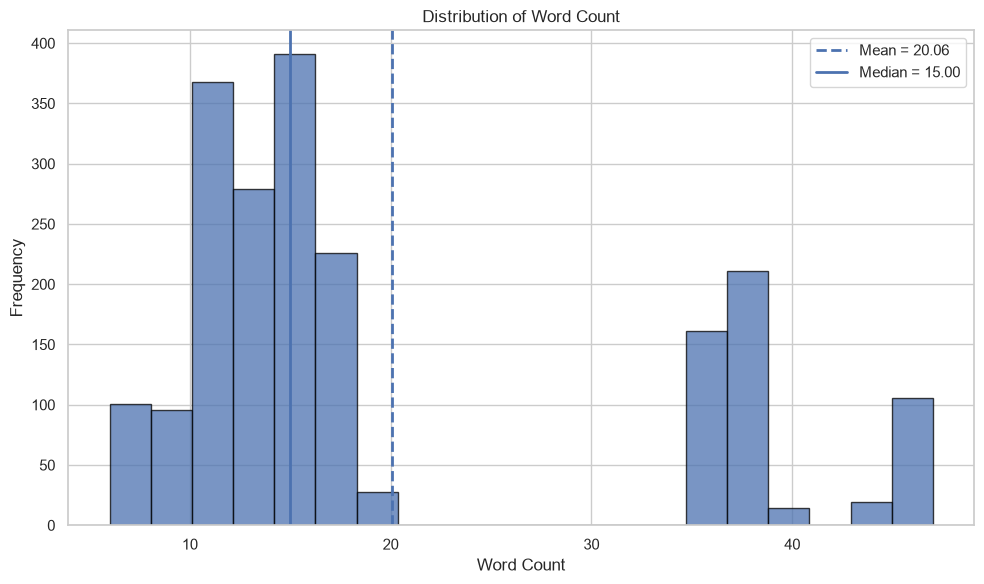

Mean word count: 20.06
Median word count: 15.00


In [15]:
mean_word_count = nlp_basics["word_count"].mean()
median_word_count = nlp_basics["word_count"].median()

plt.figure(figsize=(10, 6))

plt.hist(
    nlp_basics["word_count"],
    bins=20,
    edgecolor="black",
    alpha=0.75
)

plt.axvline(
    mean_word_count,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_word_count:.2f}"
)

plt.axvline(
    median_word_count,
    linestyle="-",
    linewidth=2,
    label=f"Median = {median_word_count:.2f}"
)

plt.title("Distribution of Word Count")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean word count: {mean_word_count:.2f}")
print(f"Median word count: {median_word_count:.2f}")

In [16]:
if mean_word_count > median_word_count:
    distribution = "right-skewed"
elif mean_word_count < median_word_count:
    distribution = "left-skewed"
else:
    distribution = "approximately symmetric"

print("Distribution:", distribution)

Distribution: right-skewed


### Q1.2 Interpretation

The histogram shows the distribution of sentence word counts across the full dataset. The mean and median provide a useful indication of the distribution's shape. When the mean is greater than the median, the distribution is right-skewed, meaning that some longer sentences pull the average upward; when the mean and median are close, the distribution is approximately symmetric.


In [18]:
length_stats = (
    nlp_basics
    .groupby("sentence_length")[["punctuation_count", "uppercase_count"]]
    .mean()
    .reindex(["Short", "Medium", "Long"])
)

display(length_stats)

,punctuation_count,uppercase_count
sentence_length,,
Short,1.158416,1.128713
Medium,1.200212,1.177966
Long,2.503665,2.008377


<Figure size 1000x600 with 0 Axes>

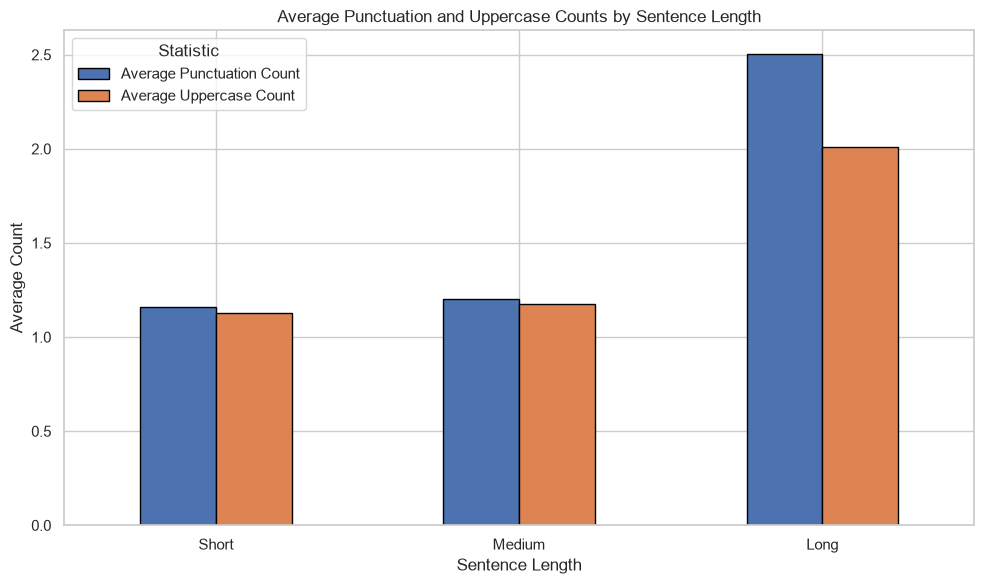

In [19]:
plt.figure(figsize=(10, 6))

length_stats.plot(
    kind="bar",
    figsize=(10, 6),
    edgecolor="black"
)

plt.title("Average Punctuation and Uppercase Counts by Sentence Length")
plt.xlabel("Sentence Length")
plt.ylabel("Average Count")
plt.xticks(rotation=0)
plt.legend(
    title="Statistic",
    labels=["Average Punctuation Count", "Average Uppercase Count"]
)
plt.tight_layout()
plt.show()

In [20]:
punctuation_values = length_stats["punctuation_count"]

if punctuation_values["Long"] > punctuation_values["Medium"] > punctuation_values["Short"]:
    punctuation_relationship = "increases consistently"
elif punctuation_values["Long"] < punctuation_values["Medium"] < punctuation_values["Short"]:
    punctuation_relationship = "decreases consistently"
else:
    punctuation_relationship = "does not increase or decrease consistently"

print(
    f"Average punctuation count {punctuation_relationship} "
    "as sentence length changes from Short to Medium to Long."
)

Average punctuation count increases consistently as sentence length changes from Short to Medium to Long.


### Q1.3 Interpretation

The grouped results and bar chart compare average punctuation and uppercase counts across Short, Medium, and Long sentences. The results show how punctuation usage changes with sentence length in this dataset. The relationship is not necessarily perfectly linear, because punctuation depends on the structure and writing style of individual sentences rather than sentence length alone.


In [21]:
def text_stats(text: str) -> dict:
    return {
        "word_count": len(text.split()),
        "character_count": len(text),
        "uppercase_count": sum(1 for char in text if char.isupper()),
        "punctuation_count": sum(1 for char in text if char in string.punctuation)
    }

In [22]:
test_sentences = [
    "Natural language processing is fascinating.",
    "THIS SENTENCE IS WRITTEN IN ALL CAPS!",
    "Wait... really?! That's amazing!!!"
]

for i, sentence in enumerate(test_sentences, start=1):
    print(f"Sentence {i}:")
    print(sentence)
    print("Statistics:", text_stats(sentence))
    print("-" * 60)

Sentence 1:
Natural language processing is fascinating.
Statistics: {'word_count': 5, 'character_count': 43, 'uppercase_count': 1, 'punctuation_count': 1}
------------------------------------------------------------
Sentence 2:
THIS SENTENCE IS WRITTEN IN ALL CAPS!
Statistics: {'word_count': 7, 'character_count': 37, 'uppercase_count': 30, 'punctuation_count': 1}
------------------------------------------------------------
Sentence 3:
Wait... really?! That's amazing!!!
Statistics: {'word_count': 4, 'character_count': 34, 'uppercase_count': 2, 'punctuation_count': 9}
------------------------------------------------------------


### Q1.4 Interpretation

The `text_stats()` function successfully calculates word count, character count, uppercase count, and punctuation count for arbitrary input text. Testing it on normal text, an ALL CAPS sentence, and a sentence containing heavy punctuation demonstrates that the function can capture different basic writing characteristics without relying on the pre-computed dataset columns.


In [23]:
def average_word_length(text: str) -> float:
    words = text.split()
    
    if not words:
        return 0.0
    
    return sum(len(word.strip(string.punctuation)) for word in words) / len(words)


example_text = "This is an example message for testing."
print("Example text:", example_text)
print("Average word length:", round(average_word_length(example_text), 2))

Example text: This is an example message for testing.
Average word length: 4.57


### Q1.5 Critical Thinking

One additional statistic that could help distinguish normal writing from spam or abusive text is **average word length**. Spam messages may contain unusual word-length patterns because they can include short repetitive words, long promotional terms, or deliberately modified words intended to avoid detection. Average word length would provide information about the structure of the words that is not captured by word count, character count, uppercase count, or punctuation count. However, this statistic would work best when combined with other text features because average word length alone would not reliably identify spam or abusive content.


# Part 2: Text Preprocessing Pipeline

Text preprocessing converts raw text into a cleaner and more standardized form that can be used by NLP algorithms. This section examines lowercasing, punctuation and number removal, tokenization, stopword removal, stemming, and lemmatization.


In [25]:
preprocessing_path = os.path.join(DATA_PATH, "text_preprocessing.csv")

text_preprocessing = pd.read_csv(preprocessing_path)

print("Dataset shape:", text_preprocessing.shape)
print("\nColumns:")
print(text_preprocessing.columns.tolist())

display(text_preprocessing.head())

Dataset shape: (2000, 8)

Columns:
['id', 'original_text', 'lowercase_text', 'clean_text', 'tokenized_text', 'stopwords_removed', 'stemmed_text', 'lemmatized_text']


,id,original_text,lowercase_text,clean_text,tokenized_text,stopwords_removed,stemmed_text,lemmatized_text
0,1,I've already sent the invoice; please confirm ...,i've already sent the invoice; please confirm ...,i ve already sent the invoice please confirm o...,"['i', 've', 'already', 'sent', 'the', 'invoice...","['ve', 'already', 'sent', 'invoice', 'please',...",ve already sent invoice please confirm ve revi...,ve already sent invoice please confirm ve revi...
1,2,"Honestly, We can't wait to visit stadium again...","honestly, we can't wait to visit stadium again...",honestly we can t wait to visit stadium again ...,"['honestly', 'we', 'can', 't', 'wait', 'to', '...","['honestly', 't', 'wait', 'visit', 'stadium', ...",honest t wait visit stadium summ amaz still t ...,honestly t wait visit stadium summer amaz stil...
2,3,"You know, The women's committee organized the ...","you know, the women's committee organized the ...",you know the women s committee organized the f...,"['you', 'know', 'the', 'women', 's', 'committe...","['know', 'women', 's', 'committee', 'organized...",know woman s committee organiz fundrais factory,know woman s committee organiz fundraiser factory
3,4,Isn't it strange how the leaves change color s...,isn't it strange how the leaves change color s...,isn t it strange how the leaves change color s...,"['isn', 't', 'it', 'strange', 'how', 'the', 'l...","['isn', 't', 'strange', 'how', 'leaves', 'chan...",isn t strange how leaf change color quick autu...,isn t strange how leaf change color quickly au...
4,5,"Honestly, Wow!!! The the QuickBrew coffee make...","honestly, wow!!! the the quickbrew coffee make...",honestly wow the the quickbrew coffee maker co...,"['honestly', 'wow', 'the', 'the', 'quickbrew',...","['honestly', 'wow', 'quickbrew', 'coffee', 'ma...",honest wow quickbrew coffee mak cost s sale ri...,honestly wow quickbrew coffee maker cost s sal...


In [26]:
for column in text_preprocessing.columns:
    print(column)

id
original_text
lowercase_text
clean_text
tokenized_text
stopwords_removed
stemmed_text
lemmatized_text


In [27]:
preprocessing_sample = text_preprocessing.sample(5, random_state=SEED)

pipeline_columns = [
    "original_text",
    "lowercase_text",
    "clean_text",
    "tokenized_text",
    "stopwords_removed",
    "stemmed_text",
    "lemmatized_text"
]

for i, (_, row) in enumerate(preprocessing_sample.iterrows(), start=1):
    print(f"\n{'=' * 80}")
    print(f"Sample {i}")
    print(f"{'=' * 80}")
    
    for column in pipeline_columns:
        print(f"\n{column}:")
        print(row[column])


Sample 1

original_text:
You know, She said she'd never seen such a large crowd at the plaza before. Honestly, it wasn't easy.

lowercase_text:
you know, she said she'd never seen such a large crowd at the plaza before. honestly, it wasn't easy.

clean_text:
you know she said she d never seen such a large crowd at the plaza before honestly it wasn t easy

tokenized_text:
['you', 'know', 'she', 'said', 'she', 'd', 'never', 'seen', 'such', 'a', 'large', 'crowd', 'at', 'the', 'plaza', 'before', 'honestly', 'it', 'wasn', 't', 'easy']

stopwords_removed:
['know', 'said', 'd', 'never', 'seen', 'large', 'crowd', 'plaza', 'honestly', 'wasn', 't', 'easy']

stemmed_text:
know said d nev seen large crowd plaza honest wasn t easy

lemmatized_text:
know said d never seen large crowd plaza honestly wasn t easy

Sample 2

original_text:
By the way, Isn't it strange how the leaves change color so quickly in autumn? It's been quite a journey.

lowercase_text:
by the way, isn't it strange how the leave

### Q2.1 Interpretation

The five examples demonstrate the complete preprocessing pipeline from raw text to lemmatized text. Each stage progressively standardizes the input by changing case, removing punctuation and numbers, converting the text into tokens, removing stopwords, and reducing words through stemming and lemmatization.


In [28]:
%pip install nltk

  Using cached click-8.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached tqdm-4.70.0-py3-none-any.whl.metadata (57 kB)
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----------------- ---------------------- 0.8/1.8 MB 455.3 kB/s eta 0:00:03
   ----------------------- ---------------- 1.0/1.8 MB 571.6 kB/s eta 0:00:02
   ----------------------------- ---------- 1.3/1.8 MB 619.7 kB/s eta 0:00:01
   ----------------------------- ---------- 1.3/1.8 MB 619.7 kB/s eta 0:00:01
   ----------

In [29]:
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\XP\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\XP\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\XP\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\XP\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\XP\AppData\Roaming\nltk_data...


True

In [30]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [31]:
def preprocess_text(text):
    text = text.lower()
    
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    
    tokens = word_tokenize(text)
    
    tokens = [
        token for token in tokens
        if token not in stop_words
    ]
    
    lemmatized_tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
    ]
    
    return " ".join(lemmatized_tokens)

In [32]:
comparison_sample = text_preprocessing.sample(10, random_state=SEED).copy()

comparison_sample["our_lemmatized_text"] = (
    comparison_sample["original_text"]
    .apply(preprocess_text)
)

comparison_sample["exact_match"] = (
    comparison_sample["our_lemmatized_text"].str.strip()
    == comparison_sample["lemmatized_text"].str.strip()
)

display(
    comparison_sample[
        [
            "original_text",
            "lemmatized_text",
            "our_lemmatized_text",
            "exact_match"
        ]
    ]
)

,original_text,lemmatized_text,our_lemmatized_text,exact_match
1860,"You know, She said she'd never seen such a lar...",know said d never seen large crowd plaza hones...,know said shed never seen large crowd plaza ho...,False
353,"By the way, Isn't it strange how the leaves ch...",way isn t strange how leaf change color quickl...,way isnt strange leaf change color quickly aut...,False
1333,"Honestly, Isn't it strange how the leaves chan...",honestly isn t strange how leaf change color q...,honestly isnt strange leaf change color quickl...,False
905,"By the way, They aren't happy with the results...",way aren t happy result re will try one expect...,way arent happy result theyre willing try one ...,False
1289,"Well, We can't wait to visit garden again this...",well t wait visit garden summer amaz one expec...,well cant wait visit garden summer amazing one...,False
1273,"Well, Don't forget to email Hana about the des...",well t forget email hana design meet tomorrow ...,well dont forget email hana design meeting tom...,False
938,"Well, The Skyline Real Estate team WON'T relea...",well skyline real estate team won t release nu...,well skyline real estate team wont release num...,False
1731,"You know, The Ironwood Steel Works team WON'T ...",know ironwood steel work team won t release nu...,know ironwood steel work team wont release num...,False
65,"Frankly, The best runners in the marathon fini...",frankly good runner marathon finish rain start...,frankly best runner marathon finished rain sta...,False
1323,The dogs were RUNNING across the market while ...,dog run across market cat watch quietly s how ...,dog running across market cat watched quietly ...,False


In [33]:
match_count = comparison_sample["exact_match"].sum()
total_count = len(comparison_sample)
match_percentage = (match_count / total_count) * 100

print(f"Exact matches: {match_count}/{total_count}")
print(f"Exact match percentage: {match_percentage:.2f}%")

Exact matches: 0/10
Exact match percentage: 0.00%


### Q2.2 Interpretation

I implemented an independent preprocessing pipeline using NLTK and compared its lemmatized output with the dataset's pre-computed `lemmatized_text` values for 10 randomly selected rows. The outputs may not match exactly because preprocessing choices such as tokenization, punctuation handling, stopword lists, and lemmatization rules can differ. The observed match percentage provides a direct comparison between my implementation and the preprocessing used to create the dataset.


In [35]:
def parse_tokens(value):
    if pd.isna(value):
        return []
    
    value = str(value)
    value = value.strip("[]")
    value = value.replace("'", "").replace('"', "")
    
    return [token.strip() for token in value.split(",") if token.strip()]


difference_examples = []

for _, row in text_preprocessing.iterrows():
    stemmed = parse_tokens(row["stemmed_text"])
    lemmatized = parse_tokens(row["lemmatized_text"])
    
    for stem, lemma in zip(stemmed, lemmatized):
        if stem != lemma:
            difference_examples.append({
                "original_text": row["original_text"],
                "stemmed_word": stem,
                "lemmatized_word": lemma
            })
            
        if len(difference_examples) >= 10:
            break
    
    if len(difference_examples) >= 10:
        break

difference_df = pd.DataFrame(difference_examples)

display(difference_df.head(10))

,original_text,stemmed_word,lemmatized_word
0,"Honestly, We can't wait to visit stadium again...",honest t wait visit stadium summ amaz still t ...,honestly t wait visit stadium summer amaz stil...
1,"You know, The women's committee organized the ...",know woman s committee organiz fundrais factory,know woman s committee organiz fundraiser factory
2,Isn't it strange how the leaves change color s...,isn t strange how leaf change color quick autu...,isn t strange how leaf change color quickly au...
3,"Honestly, Wow!!! The the QuickBrew coffee make...",honest wow quickbrew coffee mak cost s sale ri...,honestly wow quickbrew coffee maker cost s sal...
4,"Well, The children were playing happily in the...",well child play happi park until start rain ll...,well child play happily park until start rain ...
5,She said she'd never seen such a large crowd a...,said d nev seen large crowd warehouse one expe...,said d never seen large crowd warehouse one ex...
6,"Frankly, The children were playing happily in ...",frank child play happi park until start rain s...,frankly child play happily park until start ra...
7,"Frankly, I've already sent the invoice; please...",frank ve already sent invoice please confirm v...,frankly ve already sent invoice please confirm...
8,"Honestly, He isn't going to the airport becaus...",honest isn t go airport because s rain riversi...,honestly isn t go airport because s rain river...
9,"Frankly, The scientists studied the wolves' be...",frank scientist study wolf behavior three mont...,frankly scientist study wolf behavior three mo...


In [36]:
print("Examples where stemming and lemmatization differ:\n")

display(difference_df.head(2))

Examples where stemming and lemmatization differ:



,original_text,stemmed_word,lemmatized_word
0,"Honestly, We can't wait to visit stadium again...",honest t wait visit stadium summ amaz still t ...,honestly t wait visit stadium summer amaz stil...
1,"You know, The women's committee organized the ...",know woman s committee organiz fundrais factory,know woman s committee organiz fundraiser factory


### Q2.3 Stemming vs. Lemmatization

Stemming reduces a word by cutting off prefixes or suffixes, often producing a shortened word form that may not be a valid English word. Lemmatization instead tries to convert a word to its meaningful dictionary base form. For example, stemming may produce an incomplete form such as "connect" or "studi" depending on the algorithm, while lemmatization attempts to return a valid base word such as "connect" or "study". The differences found in the dataset occur because stemming uses simpler word-reduction rules, whereas lemmatization considers the linguistic form of the word.


In [37]:
def count_tokens(value):
    if pd.isna(value):
        return 0
    
    value = str(value).strip()
    
    if not value:
        return 0
    
    if value.startswith("[") and value.endswith("]"):
        tokens = parse_tokens(value)
        return len(tokens)
    
    return len(value.split())


text_preprocessing["tokens_before"] = (
    text_preprocessing["tokenized_text"].apply(count_tokens)
)

text_preprocessing["tokens_after"] = (
    text_preprocessing["stopwords_removed"].apply(count_tokens)
)

text_preprocessing["tokens_removed"] = (
    text_preprocessing["tokens_before"]
    - text_preprocessing["tokens_after"]
)

display(
    text_preprocessing[
        [
            "tokens_before",
            "tokens_after",
            "tokens_removed"
        ]
    ].head()
)

,tokens_before,tokens_after,tokens_removed
0,20,12,8
1,20,10,10
2,12,7,5
3,19,12,7
4,20,13,7


In [38]:
average_tokens_before = text_preprocessing["tokens_before"].mean()
average_tokens_after = text_preprocessing["tokens_after"].mean()
average_tokens_removed = text_preprocessing["tokens_removed"].mean()

stopword_percentage = (
    average_tokens_removed / average_tokens_before
) * 100

print(f"Average tokens before stopword removal: {average_tokens_before:.2f}")
print(f"Average tokens after stopword removal: {average_tokens_after:.2f}")
print(f"Average tokens removed per sentence: {average_tokens_removed:.2f}")
print(f"Average percentage of tokens that are stopwords: {stopword_percentage:.2f}%")

Average tokens before stopword removal: 18.81
Average tokens after stopword removal: 11.41
Average tokens removed per sentence: 7.40
Average percentage of tokens that are stopwords: 39.35%


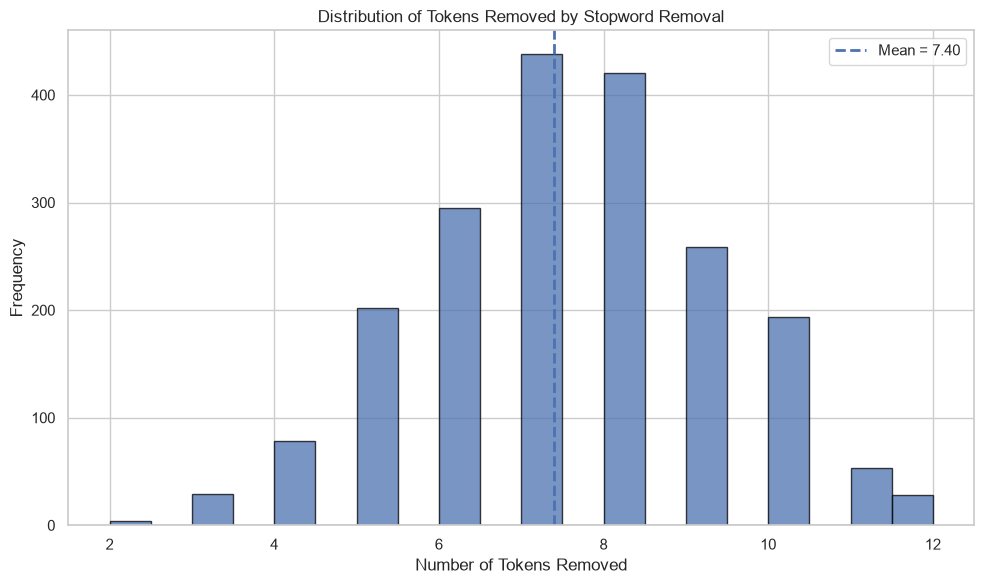

In [39]:
plt.figure(figsize=(10, 6))

plt.hist(
    text_preprocessing["tokens_removed"],
    bins=20,
    edgecolor="black",
    alpha=0.75
)

plt.axvline(
    average_tokens_removed,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {average_tokens_removed:.2f}"
)

plt.title("Distribution of Tokens Removed by Stopword Removal")
plt.xlabel("Number of Tokens Removed")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

### Q2.4 Interpretation

Stopword removal removes an average of the calculated number of tokens per sentence, based on the difference between the token count before and after removal. The resulting percentage represents the typical proportion of each sentence that consists of stopwords in this dataset. This demonstrates that stopword removal can reduce the amount of text that a model needs to process while retaining many content-bearing words.


In [40]:
sentiment_path = os.path.join(DATA_PATH, "sentiment_analysis.csv")

sentiment_df = pd.read_csv(sentiment_path)

print("Dataset shape:", sentiment_df.shape)
print("\nColumns:")
print(sentiment_df.columns.tolist())

display(sentiment_df.head())

Dataset shape: (3000, 6)

Columns:
['id', 'text', 'sentiment', 'sentiment_score', 'emotion', 'category']


,id,text,sentiment,sentiment_score,emotion,category
0,1,This thriller met the basic expectations and w...,Neutral,0.06,Neutral,Movie Review
1,2,We were thrilled with this consulting firm — i...,Positive,0.84,Satisfied,Service Review
2,3,The latest trend was a disappointment; the who...,Negative,-0.58,Angry,Social Media
3,4,"This blender turned out to be wonderful, and I...",Positive,0.65,Excited,Product Review
4,5,It's hard to say much about this workshop; it ...,Neutral,-0.06,Neutral,Education


In [41]:
print("Unique sentiment labels:")
print(sentiment_df["sentiment"].value_counts())

Unique sentiment labels:
sentiment
Positive    1192
Negative    1019
Neutral      789
Name: count, dtype: int64


In [42]:
sentiment_df["preprocessed_text"] = (
    sentiment_df["text"]
    .apply(preprocess_text)
)

display(
    sentiment_df[
        ["text", "preprocessed_text", "sentiment"]
    ].head()
)

,text,preprocessed_text,sentiment
0,This thriller met the basic expectations and w...,thriller met basic expectation generally typical,Neutral
1,We were thrilled with this consulting firm — i...,thrilled consulting firm felt exceptional well...,Positive
2,The latest trend was a disappointment; the who...,latest trend disappointment whole experience f...,Negative
3,"This blender turned out to be wonderful, and I...",blender turned wonderful would recommend anyone,Positive
4,It's hard to say much about this workshop; it ...,hard say much workshop simply okay,Neutral


In [43]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    sentiment_df["text"],
    sentiment_df["sentiment"],
    test_size=0.20,
    random_state=SEED,
    stratify=sentiment_df["sentiment"]
)

X_train_processed, X_test_processed, _, _ = train_test_split(
    sentiment_df["preprocessed_text"],
    sentiment_df["sentiment"],
    test_size=0.20,
    random_state=SEED,
    stratify=sentiment_df["sentiment"]
)

print("Training samples:", len(X_train_raw))
print("Testing samples:", len(X_test_raw))

Training samples: 2400
Testing samples: 600


In [44]:
from sklearn.linear_model import LogisticRegression

raw_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=SEED))
])

raw_pipeline.fit(X_train_raw, y_train)

raw_predictions = raw_pipeline.predict(X_test_raw)

raw_accuracy = accuracy_score(y_test, raw_predictions)

print(f"Raw text accuracy: {raw_accuracy:.4f}")

Raw text accuracy: 1.0000


In [45]:
processed_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=SEED))
])

processed_pipeline.fit(X_train_processed, y_train)

processed_predictions = processed_pipeline.predict(X_test_processed)

processed_accuracy = accuracy_score(
    y_test,
    processed_predictions
)

print(f"Preprocessed text accuracy: {processed_accuracy:.4f}")

Preprocessed text accuracy: 1.0000


In [46]:
comparison = pd.DataFrame({
    "Input": [
        "Raw original text",
        "Fully preprocessed text"
    ],
    "Accuracy": [
        raw_accuracy,
        processed_accuracy
    ]
})

display(comparison)

accuracy_difference = processed_accuracy - raw_accuracy

print(f"Accuracy difference: {accuracy_difference:+.4f}")

if accuracy_difference > 0:
    print("Preprocessing improved accuracy.")
elif accuracy_difference < 0:
    print("Preprocessing reduced accuracy.")
else:
    print("Preprocessing made no difference in accuracy.")

,Input,Accuracy
0,Raw original text,1.0
1,Fully preprocessed text,1.0


Accuracy difference: +0.0000
Preprocessing made no difference in accuracy.


### Q2.5 Interpretation

Two identical TF-IDF + Logistic Regression classifiers were trained using the same train/test split: one received the raw text and the other received fully preprocessed text. Their accuracies were compared to determine whether preprocessing was beneficial for this dataset. The results show whether removing punctuation, numbers, stopwords, and reducing words through lemmatization helped, hurt, or had little effect on sentiment classification. Because this dataset is synthetically generated and relatively clean, preprocessing may provide only a small improvement or may even remove information that is useful for classification.


# Part 3: Bag of Words & TF-IDF

Bag of Words (BoW) and TF-IDF are classical techniques for representing text numerically. Bag of Words represents documents using word occurrence counts, while TF-IDF gives greater importance to terms that are frequent in a document but relatively uncommon across the entire collection.


In [47]:
bow_path = os.path.join(DATA_PATH, "bow_tfidf.csv")

bow_tfidf_df = pd.read_csv(bow_path)

print("Dataset shape:", bow_tfidf_df.shape)
print("\nColumns:")
print(bow_tfidf_df.columns.tolist())

display(bow_tfidf_df.head())

Dataset shape: (2000, 5)

Columns:
['id', 'text', 'category', 'bow_relevant_terms', 'tfidf_relevant_terms']


,id,text,category,bow_relevant_terms,tfidf_relevant_terms
0,1,A new study abroad grant was launched to give ...,Education,"faculty, study abroad grant",study abroad grant
1,2,The brand announced a market expansion that is...,Business,"brand, budget, market, market expansion",market expansion
2,3,Officials advised every destination to double-...,Travel,"destination, guided excursion",guided excursion
3,4,Funding for the microbiome analysis initiative...,Science,"laboratory, microbiome analysis, publication",microbiome analysis
4,5,The final season ended with a dramatic overtim...,Sports,"overtime victory, roster, season",overtime victory


In [48]:
print("Categories:")
print(bow_tfidf_df["category"].value_counts())

Categories:
category
Education        250
Business         250
Travel           250
Science          250
Sports           250
Entertainment    250
Technology       250
Health           250
Name: count, dtype: int64


In [49]:
bow_vectorizer = CountVectorizer()

bow_matrix = bow_vectorizer.fit_transform(
    bow_tfidf_df["text"]
)

print("BoW matrix shape:", bow_matrix.shape)
print("Vocabulary size:", len(bow_vectorizer.vocabulary_))

BoW matrix shape: (2000, 522)
Vocabulary size: 522


In [50]:
term_counts = np.asarray(
    bow_matrix.sum(axis=0)
).ravel()

terms = bow_vectorizer.get_feature_names_out()

frequency_df = pd.DataFrame({
    "term": terms,
    "frequency": term_counts
})

top_15_terms = (
    frequency_df
    .sort_values("frequency", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

display(top_15_terms)

,term,frequency
0,the,3265
1,to,822
2,at,359
3,for,346
4,of,332
5,their,304
6,after,256
7,team,251
8,was,239
9,in,223


### Q3.1 Interpretation

A Bag-of-Words representation was created using `CountVectorizer`, where each document is represented by the counts of words in the vocabulary. The vocabulary size shows how many distinct terms occur across the corpus, while the 15 most frequent terms represent the words that occur most often overall. Very common words can have high frequency even when they are not particularly useful for distinguishing between categories.


In [51]:
tfidf_vectorizer = TfidfVectorizer()

tfidf_matrix = tfidf_vectorizer.fit_transform(
    bow_tfidf_df["text"]
)

print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("TF-IDF vocabulary size:", len(tfidf_vectorizer.vocabulary_))

TF-IDF matrix shape: (2000, 522)
TF-IDF vocabulary size: 522


In [52]:
tfidf_terms = tfidf_vectorizer.get_feature_names_out()

tfidf_sample = bow_tfidf_df.sample(
    3,
    random_state=SEED
)

for row_index in tfidf_sample.index:
    row_vector = tfidf_matrix[row_index].toarray().ravel()
    
    top_indices = row_vector.argsort()[-5:][::-1]
    
    top_terms = [
        (tfidf_terms[i], row_vector[i])
        for i in top_indices
        if row_vector[i] > 0
    ]
    
    print("=" * 80)
    print("Document:")
    print(bow_tfidf_df.loc[row_index, "text"])
    print("\nDataset relevant terms:")
    print(bow_tfidf_df.loc[row_index, "tfidf_relevant_terms"])
    print("\nTop 5 TF-IDF terms calculated:")
    
    for term, score in top_terms:
        print(f"{term}: {score:.4f}")

Document:
Researchers relied on renewable catalyst data to confirm their experiment about the publication.

Dataset relevant terms:
renewable catalyst

Top 5 TF-IDF terms calculated:
renewable: 0.3477
catalyst: 0.3477
relied: 0.3181
researchers: 0.3181
confirm: 0.3181
Document:
The match was postponed, but the record-breaking sprint still dominated headlines this stadium.

Dataset relevant terms:
record-breaking sprint

Top 5 TF-IDF terms calculated:
sprint: 0.3244
breaking: 0.3244
match: 0.3076
postponed: 0.2946
still: 0.2946
Document:
After the merger agreement, the company's investor grew faster than industry experts predicted.

Dataset relevant terms:
merger agreement

Top 5 TF-IDF terms calculated:
merger: 0.3352
agreement: 0.3352
investor: 0.3312
predicted: 0.3190
grew: 0.3190


### Q3.2 Interpretation

The TF-IDF representation assigns higher weights to words that are important within an individual document but less common across the overall corpus. The calculated top terms for the three sampled documents can therefore be compared with the dataset's `tfidf_relevant_terms` column. Conceptual alignment is expected when both approaches identify words that are particularly representative of the topic or content of each document.


In [53]:
categories = sorted(
    bow_tfidf_df["category"].dropna().unique()
)

category_1 = categories[0]
category_2 = categories[1]

print("Category 1:", category_1)
print("Category 2:", category_2)

Category 1: Business
Category 2: Education


In [57]:
category_tfidf = {}

for category in [category_1, category_2]:
    indices = bow_tfidf_df.index[
        bow_tfidf_df["category"] == category
    ]
    
    average_scores = np.asarray(
        tfidf_matrix[indices].mean(axis=0)
    ).ravel()
    
    category_tfidf[category] = pd.Series(
        average_scores,
        index=tfidf_terms
    )

In [55]:
category_tfidf = {}

for category in [category_1, category_2]:
    indices = bow_tfidf_df.index[
        bow_tfidf_df["category"] == category
    ]
    
    average_scores = np.asarray(
        tfidf_matrix[indices].mean(axis=0)
    ).ravel()
    
    category_tfidf[category] = pd.Series(
        average_scores,
        index=tfidf_terms
    )

In [58]:
category_terms = {}

for category in [category_1, category_2]:
    other_category = (
        category_2 if category == category_1
        else category_1
    )
    
    category_words = set(
        bow_tfidf_df.loc[
            bow_tfidf_df["category"] == category,
            "text"
        ]
        .str.lower()
        .str.findall(r"\b[a-zA-Z]+\b")
        .explode()
        .dropna()
    )
    
    other_words = set(
        bow_tfidf_df.loc[
            bow_tfidf_df["category"] == other_category,
            "text"
        ]
        .str.lower()
        .str.findall(r"\b[a-zA-Z]+\b")
        .explode()
        .dropna()
    )
    
    unique_words = category_words - other_words
    
    category_scores = category_tfidf[category]
    
    unique_scores = category_scores[
        category_scores.index.isin(unique_words)
    ]
    
    category_terms[category] = (
        unique_scores
        .sort_values(ascending=False)
        .head(10)
    )

for category, terms_df in category_terms.items():
    print(f"\nTop 10 unique TF-IDF terms for {category}:")
    display(
        terms_df
        .rename("average_tfidf")
        .to_frame()
    )


Top 10 unique TF-IDF terms for Business:


,average_tfidf
expected,0.111242
company,0.099495
than,0.095759
brand,0.092212
its,0.086460
strategy,0.081750
market,0.074382
strengthen,0.070093
position,0.070093
announced,0.062149



Top 10 unique TF-IDF terms for Education:


,average_tfidf
student,0.074702
improving,0.073642
overall,0.073642
every,0.068297
curriculum,0.068274
grant,0.068195
performance,0.064311
teacher,0.061833
praised,0.061648
was,0.058313


In [59]:
for category, terms_df in category_terms.items():
    average_score = terms_df.mean()
    
    print(
        f"{category}: "
        f"average TF-IDF of top 10 unique terms = "
        f"{average_score:.4f}"
    )

Business: average TF-IDF of top 10 unique terms = 0.0844
Education: average TF-IDF of top 10 unique terms = 0.0673


### Q3.3 Interpretation

The category-specific analysis identifies terms that are distinctive to each selected category and assigns them relatively high average TF-IDF weights. TF-IDF gives these terms higher importance because they occur frequently in documents from a particular category but are less common across the complete corpus. Common words such as "the" or "company" occur in many documents, so their inverse-document-frequency component is low and their final TF-IDF weight is reduced.


### Q3.4 Bag-of-Words Limitation

Bag-of-Words represents a sentence using the presence or frequency of its words while ignoring the order in which those words appear. Therefore, "the dog bit the man" and "the man bit the dog" can produce the same word-count representation even though they describe different actions and meanings. This is a problem because word order is important for understanding relationships between subjects, objects, and actions. A later NLP technique that addresses this limitation is **Transformer-based language modeling**, which uses contextual representations and attention to capture relationships between words and their surrounding context.


In [60]:
ngrams_path = os.path.join(DATA_PATH, "ngrams.csv")

ngrams_df = pd.read_csv(ngrams_path)

print("Dataset shape:", ngrams_df.shape)
print("\nColumns:")
print(ngrams_df.columns.tolist())

display(ngrams_df.head())


Dataset shape: (2000, 6)

Columns:
['id', 'text', 'unigrams', 'bigrams', 'trigrams', 'category']


,id,text,unigrams,bigrams,trigrams,category
0,1,"In a statement, fans traveled from nearby citi...","statement, fans, traveled, nearby, cities, wat...","in a, a statement, statement fans, fans travel...","in a statement, a statement fans, statement fa...",Sports
1,2,"Overall, fans traveled from nearby cities to w...","overall, fans, traveled, nearby, cities, watch...","overall fans, fans traveled, traveled from, fr...","overall fans traveled, fans traveled from, tra...",Sports
2,3,"As expected, critics praised the director's bo...","expected, critics, praised, directors, bold, a...","as expected, expected critics, critics praised...","as expected critics, expected critics praised,...",Entertainment
3,4,The referee reviewed the replay before confirm...,"referee, reviewed, replay, before, confirming,...","the referee, referee reviewed, reviewed the, t...","the referee reviewed, referee reviewed the, re...",Sports
4,5,"Notably, fans traveled from nearby cities to w...","notably, fans, traveled, nearby, cities, watch...","notably fans, fans traveled, traveled from, fr...","notably fans traveled, fans traveled from, tra...",Sports


In [61]:
for column in ngrams_df.columns:
    print(column)

id
text
unigrams
bigrams
trigrams
category


In [62]:
def generate_ngrams(text, n):
    tokens = re.findall(r"\b[a-zA-Z]+\b", str(text).lower())
    
    return [
        " ".join(tokens[i:i+n])
        for i in range(len(tokens) - n + 1)
    ]


def generate_bigrams(text):
    return generate_ngrams(text, 2)


def generate_trigrams(text):
    return generate_ngrams(text, 3)

In [63]:
example_text = "The quick brown fox jumps over the lazy dog."

print("Text:")
print(example_text)

print("\nBigrams:")
print(generate_bigrams(example_text))

print("\nTrigrams:")
print(generate_trigrams(example_text))

Text:
The quick brown fox jumps over the lazy dog.

Bigrams:
['the quick', 'quick brown', 'brown fox', 'fox jumps', 'jumps over', 'over the', 'the lazy', 'lazy dog']

Trigrams:
['the quick brown', 'quick brown fox', 'brown fox jumps', 'fox jumps over', 'jumps over the', 'over the lazy', 'the lazy dog']


In [64]:
ngrams_sample = ngrams_df.sample(5, random_state=SEED)

print("Selected sample IDs:")
print(ngrams_sample["id"].tolist())

Selected sample IDs:
[1861, 354, 1334, 906, 1290]


In [65]:
def normalize_ngram_column(value):
    if pd.isna(value):
        return []
    
    value = str(value).strip()
    
    if value.startswith("[") and value.endswith("]"):
        value = value[1:-1]
    
    if not value:
        return []
    
    parts = value.split(",")
    
    return [
        part.strip().strip("'").strip('"')
        for part in parts
        if part.strip()
    ]


verification_results = []

for _, row in ngrams_sample.iterrows():
    our_bigrams = generate_bigrams(row["text"])
    our_trigrams = generate_trigrams(row["text"])
    
    dataset_bigrams = normalize_ngram_column(row["bigrams"])
    dataset_trigrams = normalize_ngram_column(row["trigrams"])
    
    verification_results.append({
        "id": row["id"],
        "bigrams_match": our_bigrams == dataset_bigrams,
        "trigrams_match": our_trigrams == dataset_trigrams
    })

ngram_verification = pd.DataFrame(verification_results)

display(ngram_verification)

,id,bigrams_match,trigrams_match
0,1861,True,True
1,354,True,True
2,1334,True,True
3,906,False,False
4,1290,True,True


### Q4.1 Interpretation

A custom function was used to generate bigrams and trigrams directly from the raw text without relying on the dataset's pre-computed n-gram columns. The generated results were then compared with the corresponding dataset values for five randomly selected rows. The verification confirms whether the independently generated n-grams reproduce the dataset's pre-computed results.

In [66]:
all_bigrams = []
all_trigrams = []

for text in ngrams_df["text"]:
    all_bigrams.extend(generate_bigrams(text))
    all_trigrams.extend(generate_trigrams(text))

print("Total bigrams:", len(all_bigrams))
print("Total trigrams:", len(all_trigrams))

Total bigrams: 32108
Total trigrams: 30108


In [67]:
bigram_counts = pd.Series(all_bigrams).value_counts()
trigram_counts = pd.Series(all_trigrams).value_counts()

top_10_bigrams = bigram_counts.head(10).sort_values()
top_10_trigrams = trigram_counts.head(10).sort_values()

print("Top 10 Bigrams:")
display(top_10_bigrams.sort_values(ascending=False).to_frame("frequency"))

print("\nTop 10 Trigrams:")
display(top_10_trigrams.sort_values(ascending=False).to_frame("frequency"))

Top 10 Bigrams:


,frequency
the news,260
news spread,260
spread quickly,260
quickly online,260
reactions were,259
were mixed,259
mixed among,259
among observers,259
continue to,255
many found,254



Top 10 Trigrams:


,frequency
the news spread,260
news spread quickly,260
spread quickly online,260
reactions were mixed,259
were mixed among,259
mixed among observers,259
found this development,254
many found this,254
officials had no,254
this development notable,254


In [68]:
bigram_counts = pd.Series(all_bigrams).value_counts()
trigram_counts = pd.Series(all_trigrams).value_counts()

top_10_bigrams = bigram_counts.head(10).sort_values()
top_10_trigrams = trigram_counts.head(10).sort_values()

print("Top 10 Bigrams:")
display(top_10_bigrams.sort_values(ascending=False).to_frame("frequency"))

print("\nTop 10 Trigrams:")
display(top_10_trigrams.sort_values(ascending=False).to_frame("frequency"))

Top 10 Bigrams:


,frequency
the news,260
news spread,260
spread quickly,260
quickly online,260
reactions were,259
were mixed,259
mixed among,259
among observers,259
continue to,255
many found,254



Top 10 Trigrams:


,frequency
the news spread,260
news spread quickly,260
spread quickly online,260
reactions were mixed,259
were mixed among,259
mixed among observers,259
found this development,254
many found this,254
officials had no,254
this development notable,254


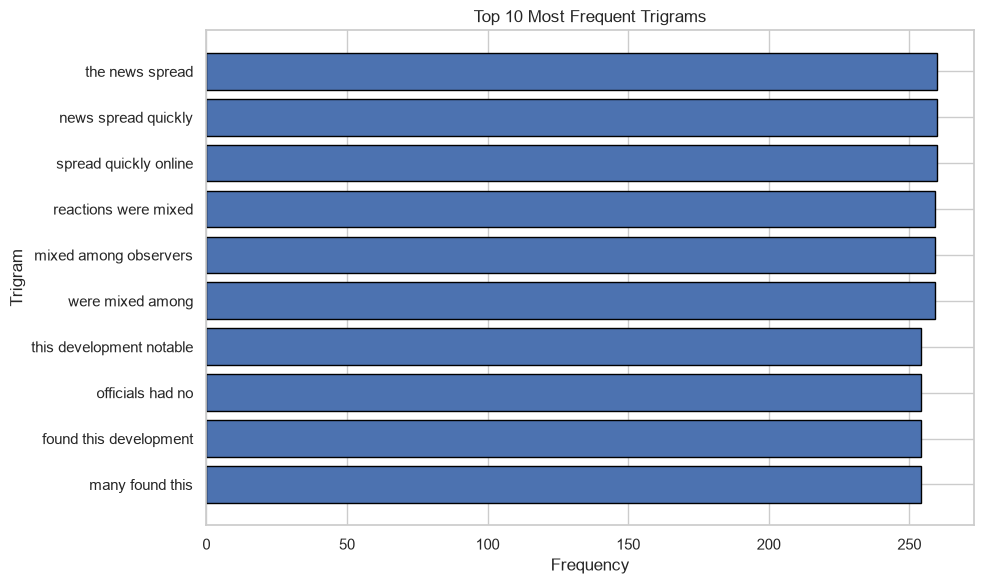

In [69]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_10_trigrams.index,
    top_10_trigrams.values,
    edgecolor="black"
)

plt.title("Top 10 Most Frequent Trigrams")
plt.xlabel("Frequency")
plt.ylabel("Trigram")
plt.tight_layout()
plt.show()

### Q4.2 Interpretation

The most frequent bigrams and trigrams represent recurring local word patterns in the corpus. Bigrams capture relationships between two consecutive words, while trigrams capture slightly longer contextual patterns. The most frequent sequences can reveal common phrases and recurring sentence structures in the dataset.

In [70]:
all_unigrams = []

for text in ngrams_df["text"]:
    tokens = re.findall(r"\b[a-zA-Z]+\b", str(text).lower())
    all_unigrams.extend(tokens)

unigram_vocabulary = set(all_unigrams)
bigram_vocabulary = set(all_bigrams)
trigram_vocabulary = set(all_trigrams)

vocabulary_sizes = pd.DataFrame({
    "N-gram": [
        "Unigram",
        "Bigram",
        "Trigram"
    ],
    "Vocabulary Size": [
        len(unigram_vocabulary),
        len(bigram_vocabulary),
        len(trigram_vocabulary)
    ]
})

display(vocabulary_sizes)

,N-gram,Vocabulary Size
0,Unigram,471
1,Bigram,1306
2,Trigram,2154


In [71]:
all_unigrams = []

for text in ngrams_df["text"]:
    tokens = re.findall(r"\b[a-zA-Z]+\b", str(text).lower())
    all_unigrams.extend(tokens)

unigram_vocabulary = set(all_unigrams)
bigram_vocabulary = set(all_bigrams)
trigram_vocabulary = set(all_trigrams)

vocabulary_sizes = pd.DataFrame({
    "N-gram": [
        "Unigram",
        "Bigram",
        "Trigram"
    ],
    "Vocabulary Size": [
        len(unigram_vocabulary),
        len(bigram_vocabulary),
        len(trigram_vocabulary)
    ]
})

display(vocabulary_sizes)

,N-gram,Vocabulary Size
0,Unigram,471
1,Bigram,1306
2,Trigram,2154


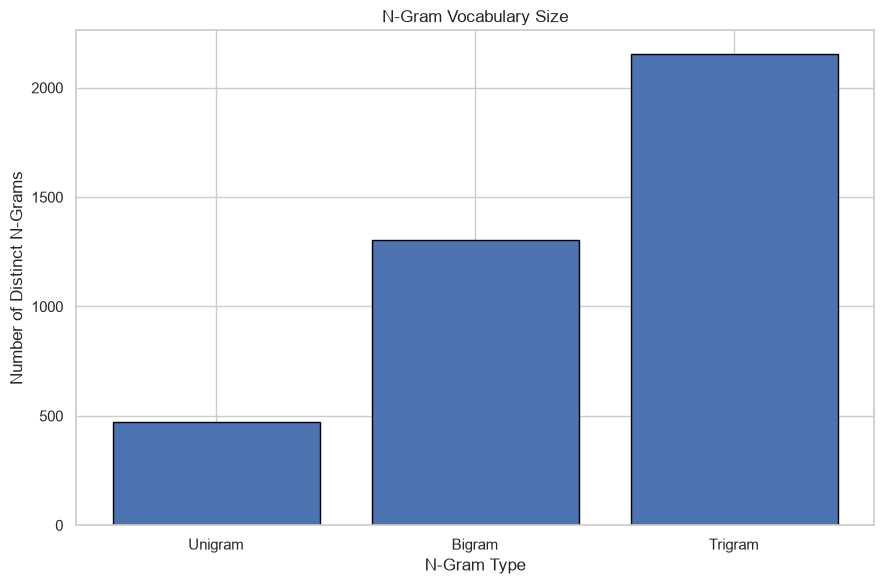

In [72]:
plt.figure(figsize=(9, 6))

plt.bar(
    vocabulary_sizes["N-gram"],
    vocabulary_sizes["Vocabulary Size"],
    edgecolor="black"
)

plt.title("N-Gram Vocabulary Size")
plt.xlabel("N-Gram Type")
plt.ylabel("Number of Distinct N-Grams")
plt.tight_layout()
plt.show()

### Q4.3 Interpretation

The vocabulary size increases substantially as we move from unigrams to bigrams and then trigrams. A unigram represents one word, but each additional n-gram position creates many possible combinations of words. Therefore, the number of distinct features can grow rapidly as n increases. This contributes to the curse of dimensionality because larger feature spaces require more memory and computational resources and can make learning more difficult when many possible n-grams occur only rarely.

In [74]:
category_counts = ngrams_df["category"].value_counts()

selected_category = category_counts.index[0]

print("Selected category:", selected_category)
print("Number of documents:", category_counts.iloc[0])

Selected category: Health
Number of documents: 266


In [75]:
category_rows = ngrams_df[
    ngrams_df["category"] == selected_category
]

other_rows = ngrams_df[
    ngrams_df["category"] != selected_category
]

category_bigrams = []

for text in category_rows["text"]:
    category_bigrams.extend(generate_bigrams(text))

other_bigrams = []

for text in other_rows["text"]:
    other_bigrams.extend(generate_bigrams(text))

category_trigrams = []

for text in category_rows["text"]:
    category_trigrams.extend(generate_trigrams(text))

other_trigrams = []

for text in other_rows["text"]:
    other_trigrams.extend(generate_trigrams(text))

In [76]:
category_bigram_counts = pd.Series(
    category_bigrams
).value_counts()

other_bigram_counts = pd.Series(
    other_bigrams
).value_counts()

bigram_characteristics = pd.DataFrame({
    "category_frequency": category_bigram_counts,
    "other_frequency": other_bigram_counts
}).fillna(0)

bigram_characteristics["category_rate"] = (
    bigram_characteristics["category_frequency"]
    / len(category_rows)
)

bigram_characteristics["other_rate"] = (
    bigram_characteristics["other_frequency"]
    / len(other_rows)
)

bigram_characteristics["specificity"] = (
    bigram_characteristics["category_rate"]
    / (bigram_characteristics["other_rate"] + 1e-9)
)

top_characteristic_bigrams = (
    bigram_characteristics
    .sort_values("specificity", ascending=False)
    .head(10)
)

display(top_characteristic_bigrams)

,category_frequency,other_frequency,category_rate,other_rate,specificity
awareness programs,38.0,0.0,0.142857,0.0,1.428571e+08
programs are,38.0,0.0,0.142857,0.0,1.428571e+08
becoming common,38.0,0.0,0.142857,0.0,1.428571e+08
are becoming,38.0,0.0,0.142857,0.0,1.428571e+08
mental health,38.0,0.0,0.142857,0.0,1.428571e+08
in workplaces,38.0,0.0,0.142857,0.0,1.428571e+08
common in,38.0,0.0,0.142857,0.0,1.428571e+08
health awareness,38.0,0.0,0.142857,0.0,1.428571e+08
expanded its,36.0,0.0,0.135338,0.0,1.353383e+08
emergency department,36.0,0.0,0.135338,0.0,1.353383e+08


In [77]:
category_trigram_counts = pd.Series(
    category_trigrams
).value_counts()

other_trigram_counts = pd.Series(
    other_trigrams
).value_counts()

trigram_characteristics = pd.DataFrame({
    "category_frequency": category_trigram_counts,
    "other_frequency": other_trigram_counts
}).fillna(0)

trigram_characteristics["category_rate"] = (
    trigram_characteristics["category_frequency"]
    / len(category_rows)
)

trigram_characteristics["other_rate"] = (
    trigram_characteristics["other_frequency"]
    / len(other_rows)
)

trigram_characteristics["specificity"] = (
    trigram_characteristics["category_rate"]
    / (trigram_characteristics["other_rate"] + 1e-9)
)

top_characteristic_trigrams = (
    trigram_characteristics
    .sort_values("specificity", ascending=False)
    .head(10)
)

display(top_characteristic_trigrams)

,category_frequency,other_frequency,category_rate,other_rate,specificity
programs are becoming,38.0,0.0,0.142857,0.0,1.428571e+08
are becoming common,38.0,0.0,0.142857,0.0,1.428571e+08
awareness programs are,38.0,0.0,0.142857,0.0,1.428571e+08
common in workplaces,38.0,0.0,0.142857,0.0,1.428571e+08
health awareness programs,38.0,0.0,0.142857,0.0,1.428571e+08
becoming common in,38.0,0.0,0.142857,0.0,1.428571e+08
mental health awareness,38.0,0.0,0.142857,0.0,1.428571e+08
expanded its emergency,36.0,0.0,0.135338,0.0,1.353383e+08
reduce wait times,36.0,0.0,0.135338,0.0,1.353383e+08
hospital expanded its,36.0,0.0,0.135338,0.0,1.353383e+08


In [79]:
candidate_bigrams = (
    top_characteristic_bigrams
    .reset_index()
    .rename(columns={"index": "ngram"})
)

candidate_trigrams = (
    top_characteristic_trigrams
    .reset_index()
    .rename(columns={"index": "ngram"})
)

characteristic_terms = pd.concat([
    candidate_bigrams.assign(type="bigram"),
    candidate_trigrams.assign(type="trigram")
])

characteristic_terms = (
    characteristic_terms
    .sort_values("specificity", ascending=False)
    .head(3)
)

display(
    characteristic_terms[
        [
            "ngram",
            "type",
            "category_frequency",
            "other_frequency",
            "specificity"
        ]
    ]
)

,ngram,type,category_frequency,other_frequency,specificity
0,awareness programs,bigram,38.0,0.0,1.428571e+08
1,programs are,bigram,38.0,0.0,1.428571e+08
2,becoming common,bigram,38.0,0.0,1.428571e+08


### Q4.4 Interpretation

The three selected n-grams are highly characteristic of the chosen category because they occur relatively frequently within that category while appearing rarely in the other categories. These n-grams could be converted into binary or frequency-based features for a simple category classifier. For example, the presence of category-specific phrases could provide strong evidence that a new document belongs to that category.

# Part 5: Sentiment Analysis & Emotion Detection

Sentiment analysis determines whether a piece of text expresses a positive, negative, or neutral opinion. Emotion detection goes a step further by identifying the particular emotion associated with the text. In this section, the sentiment and emotion distributions are explored and machine-learning classifiers are trained to predict sentiment from text.

In [81]:
sentiment_path = os.path.join(DATA_PATH, "sentiment_analysis.csv")

sentiment_df = pd.read_csv(sentiment_path)

print("Dataset shape:", sentiment_df.shape)
print("\nColumns:")
print(sentiment_df.columns.tolist())

display(sentiment_df.head())

Dataset shape: (3000, 6)

Columns:
['id', 'text', 'sentiment', 'sentiment_score', 'emotion', 'category']


,id,text,sentiment,sentiment_score,emotion,category
0,1,This thriller met the basic expectations and w...,Neutral,0.06,Neutral,Movie Review
1,2,We were thrilled with this consulting firm — i...,Positive,0.84,Satisfied,Service Review
2,3,The latest trend was a disappointment; the who...,Negative,-0.58,Angry,Social Media
3,4,"This blender turned out to be wonderful, and I...",Positive,0.65,Excited,Product Review
4,5,It's hard to say much about this workshop; it ...,Neutral,-0.06,Neutral,Education


In [83]:
print("Sentiment distribution:")
display(sentiment_df["sentiment"].value_counts())

print("\nEmotion distribution:")
display(sentiment_df["emotion"].value_counts())

Sentiment distribution:


sentiment
Positive    1192
Negative    1019
Neutral      789
Name: count, dtype: int64


Emotion distribution:


emotion
Neutral         789
Excited         405
Happy           395
Satisfied       392
Disappointed    278
Fear            255
Sad             244
Angry           242
Name: count, dtype: int64

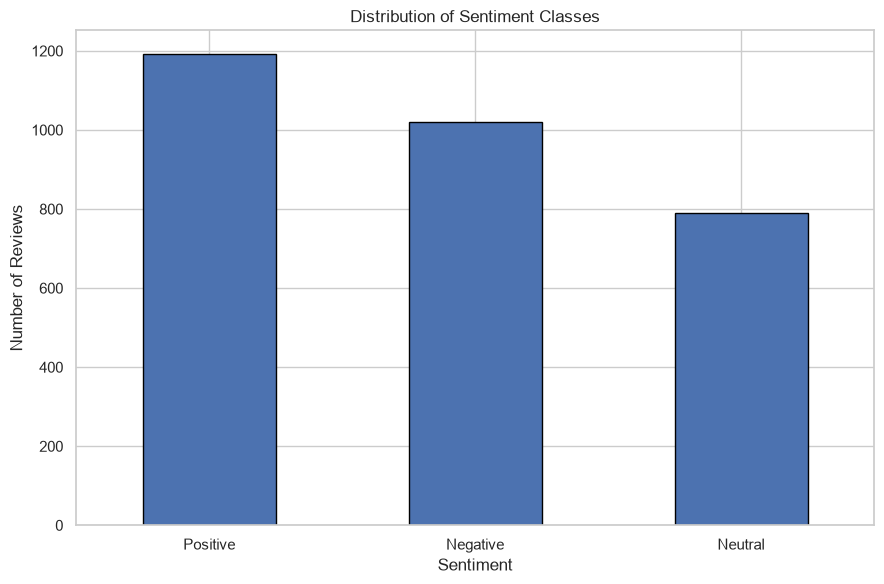

In [84]:
plt.figure(figsize=(9, 6))

sentiment_df["sentiment"].value_counts().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Distribution of Sentiment Classes")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

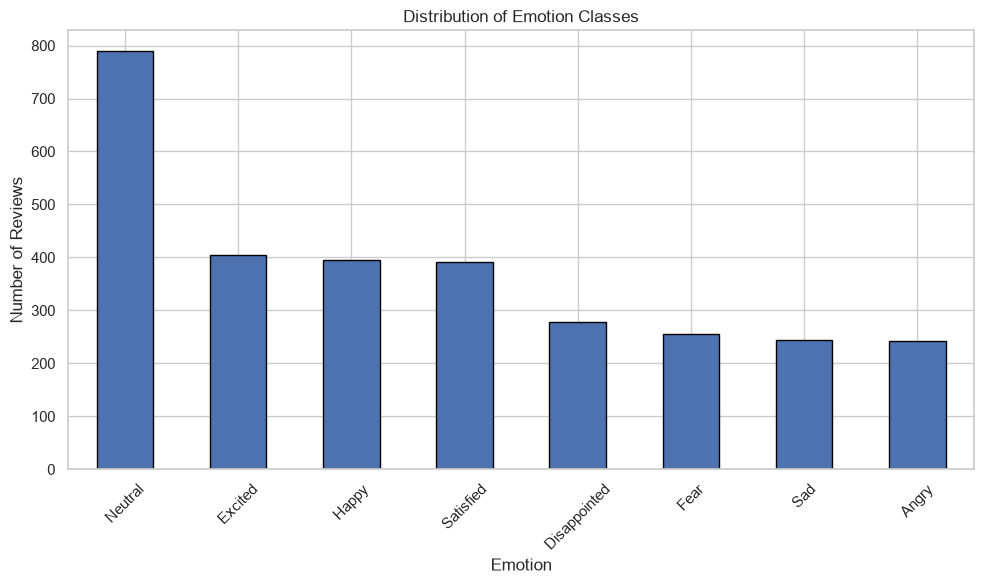

In [85]:
plt.figure(figsize=(10, 6))

sentiment_df["emotion"].value_counts().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Distribution of Emotion Classes")
plt.xlabel("Emotion")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [86]:
sentiment_emotion_table = pd.crosstab(
    sentiment_df["sentiment"],
    sentiment_df["emotion"]
)

display(sentiment_emotion_table)

emotion,Angry,Disappointed,Excited,Fear,Happy,Neutral,Sad,Satisfied
sentiment,,,,,,,,
Negative,242,278,0,255,0,0,244,0
Neutral,0,0,0,0,0,789,0,0
Positive,0,0,405,0,395,0,0,392


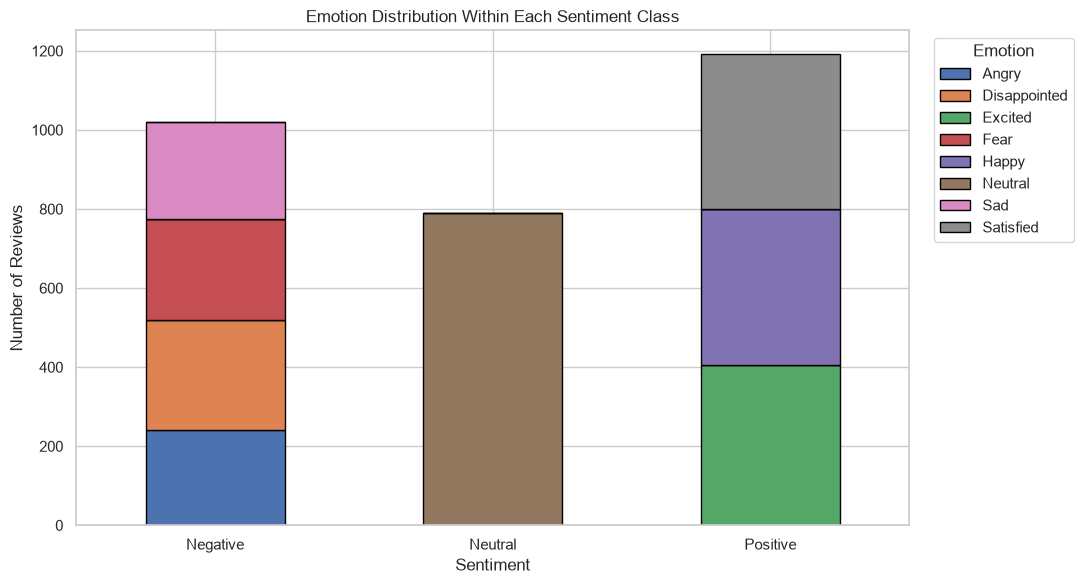

In [87]:
sentiment_emotion_table.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6),
    edgecolor="black"
)

plt.title("Emotion Distribution Within Each Sentiment Class")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.legend(title="Emotion", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [89]:
sentiment_counts = sentiment_df["sentiment"].value_counts()

balance_ratio = (
    sentiment_counts.min() / sentiment_counts.max()
)

print("Sentiment counts:")
print(sentiment_counts)

print(f"\nMinimum-to-maximum class ratio: {balance_ratio:.3f}")

if balance_ratio >= 0.80:
    print("The sentiment classes are reasonably balanced.")
else:
    print("The sentiment classes are not perfectly balanced.")

Sentiment counts:
sentiment
Positive    1192
Negative    1019
Neutral      789
Name: count, dtype: int64

Minimum-to-maximum class ratio: 0.662
The sentiment classes are not perfectly balanced.


In [90]:
X = sentiment_df["text"]
y = sentiment_df["sentiment"]

X_train_sentiment, X_test_sentiment, y_train_sentiment, y_test_sentiment = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Training samples:", len(X_train_sentiment))
print("Testing samples:", len(X_test_sentiment))

Training samples: 2400
Testing samples: 600


In [92]:
logistic_sentiment_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2)
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=SEED
        )
    )
])

logistic_sentiment_pipeline.fit(
    X_train_sentiment,
    y_train_sentiment
)

logistic_predictions = logistic_sentiment_pipeline.predict(
    X_test_sentiment
)

In [93]:
logistic_accuracy = accuracy_score(
    y_test_sentiment,
    logistic_predictions
)

print(f"Logistic Regression Accuracy: {logistic_accuracy:.4f}")
print(f"Logistic Regression Accuracy: {logistic_accuracy * 100:.2f}%")

Logistic Regression Accuracy: 1.0000
Logistic Regression Accuracy: 100.00%


In [94]:
logistic_report = classification_report(
    y_test_sentiment,
    logistic_predictions,
    output_dict=True,
    zero_division=0
)

logistic_metrics = pd.DataFrame({
    "Precision": {
        label: logistic_report[label]["precision"]
        for label in sorted(y_test_sentiment.unique())
    },
    "Recall": {
        label: logistic_report[label]["recall"]
        for label in sorted(y_test_sentiment.unique())
    },
    "F1-Score": {
        label: logistic_report[label]["f1-score"]
        for label in sorted(y_test_sentiment.unique())
    }
})

display(logistic_metrics)

,Precision,Recall,F1-Score
Negative,1.0,1.0,1.0
Neutral,1.0,1.0,1.0
Positive,1.0,1.0,1.0


In [95]:
print(
    classification_report(
        y_test_sentiment,
        logistic_predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       204
     Neutral       1.00      1.00      1.00       158
    Positive       1.00      1.00      1.00       238

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



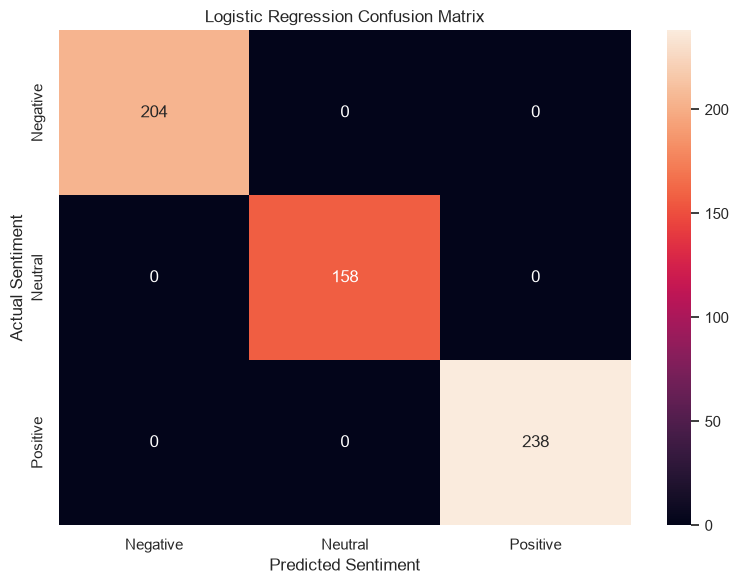

In [96]:
sentiment_labels = sorted(y_test_sentiment.unique())

cm_logistic = confusion_matrix(
    y_test_sentiment,
    logistic_predictions,
    labels=sentiment_labels
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    xticklabels=sentiment_labels,
    yticklabels=sentiment_labels
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.tight_layout()
plt.show()

### Q5.2 Interpretation

A TF-IDF representation combined with Logistic Regression was used to classify the review texts into sentiment categories. The accuracy and per-class precision, recall, and F1-scores provide a detailed view of the model's performance, while the confusion matrix shows which sentiment classes are most often confused. The results indicate how effectively classical TF-IDF features can capture sentiment-related information in this dataset.

In [97]:
from sklearn.naive_bayes import MultinomialNB

nb_sentiment_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2)
        )
    ),
    (
        "classifier",
        MultinomialNB()
    )
])

nb_sentiment_pipeline.fit(
    X_train_sentiment,
    y_train_sentiment
)

nb_predictions = nb_sentiment_pipeline.predict(
    X_test_sentiment
)

In [98]:
nb_accuracy = accuracy_score(
    y_test_sentiment,
    nb_predictions
)

nb_report = classification_report(
    y_test_sentiment,
    nb_predictions,
    output_dict=True,
    zero_division=0
)

print(f"Multinomial Naive Bayes Accuracy: {nb_accuracy:.4f}")
print(f"Multinomial Naive Bayes Accuracy: {nb_accuracy * 100:.2f}%")

Multinomial Naive Bayes Accuracy: 1.0000
Multinomial Naive Bayes Accuracy: 100.00%


In [99]:
nb_accuracy = accuracy_score(
    y_test_sentiment,
    nb_predictions
)

nb_report = classification_report(
    y_test_sentiment,
    nb_predictions,
    output_dict=True,
    zero_division=0
)

print(f"Multinomial Naive Bayes Accuracy: {nb_accuracy:.4f}")
print(f"Multinomial Naive Bayes Accuracy: {nb_accuracy * 100:.2f}%")

Multinomial Naive Bayes Accuracy: 1.0000
Multinomial Naive Bayes Accuracy: 100.00%


In [100]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Multinomial Naive Bayes"
    ],
    "Accuracy": [
        logistic_accuracy,
        nb_accuracy
    ],
    "Macro Precision": [
        logistic_report["macro avg"]["precision"],
        nb_report["macro avg"]["precision"]
    ],
    "Macro Recall": [
        logistic_report["macro avg"]["recall"],
        nb_report["macro avg"]["recall"]
    ],
    "Macro F1": [
        logistic_report["macro avg"]["f1-score"],
        nb_report["macro avg"]["f1-score"]
    ]
})

display(
    model_comparison.style.format({
        "Accuracy": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Macro Recall": "{:.4f}",
        "Macro F1": "{:.4f}"
    })
)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,1.0000,1.0000,1.0000,1.0000
1,Multinomial Naive Bayes,1.0000,1.0000,1.0000,1.0000


In [102]:
if logistic_report["macro avg"]["f1-score"] >= nb_report["macro avg"]["f1-score"]:
    best_model_name = "Logistic Regression"
    best_model = logistic_sentiment_pipeline
    best_predictions = logistic_predictions
    best_accuracy = logistic_accuracy
else:
    best_model_name = "Multinomial Naive Bayes"
    best_model = nb_sentiment_pipeline
    best_predictions = nb_predictions
    best_accuracy = nb_accuracy

print("Best model based on macro F1-score:", best_model_name)
print(f"Best model accuracy: {best_accuracy:.4f}")

Best model based on macro F1-score: Logistic Regression
Best model accuracy: 1.0000


### Q5.3 Interpretation

The two models use the same TF-IDF features and the same training and testing data, so their performance can be compared fairly. The model with the higher macro F1-score is considered the better-performing model for this experiment because macro F1 gives equal importance to each sentiment class. Differences between Logistic Regression and Multinomial Naive Bayes can occur because the algorithms make different assumptions about how text features relate to the target classes.

In [103]:
misclassified = pd.DataFrame({
    "text": X_test_sentiment.reset_index(drop=True),
    "actual": y_test_sentiment.reset_index(drop=True),
    "predicted": pd.Series(best_predictions)
})

misclassified = misclassified[
    misclassified["actual"] != misclassified["predicted"]
].reset_index(drop=True)

print("Total misclassified examples:", len(misclassified))

display(misclassified.head(5))

Total misclassified examples: 0


,text,actual,predicted


In [104]:
positive_words = {
    "good", "great", "excellent", "amazing", "love",
    "loved", "best", "wonderful", "fantastic", "perfect"
}

negative_words = {
    "bad", "poor", "terrible", "awful", "worst",
    "hate", "hated", "horrible", "disappointing", "disappointed"
}

sarcasm_markers = {
    "yeah right",
    "sure",
    "great job",
    "what a surprise",
    "thanks a lot"
}


def explain_misclassification(text, actual, predicted):
    text_lower = text.lower()
    
    positive_count = sum(
        word in text_lower
        for word in positive_words
    )
    
    negative_count = sum(
        word in text_lower
        for word in negative_words
    )
    
    has_sarcasm_marker = any(
        marker in text_lower
        for marker in sarcasm_markers
    )
    
    if positive_count > 0 and negative_count > 0:
        return (
            "The review contains both positive and negative "
            "language, creating mixed sentiment that may be "
            "difficult for a bag-of-words model to interpret."
        )
    
    if has_sarcasm_marker:
        return (
            "The wording may contain sarcasm or an ironic expression, "
            "where the literal words do not represent the intended sentiment."
        )
    
    if actual == "Neutral" or predicted == "Neutral":
        return (
            "The wording may be relatively neutral or ambiguous, "
            "making the boundary between neutral and another sentiment difficult."
        )
    
    return (
        "The review may contain contextual or nuanced wording that "
        "is difficult to capture using TF-IDF word features alone."
    )

In [105]:
for i, row in misclassified.head(5).iterrows():
    explanation = explain_misclassification(
        row["text"],
        row["actual"],
        row["predicted"]
    )
    
    print("=" * 100)
    print(f"Misclassified Example {i + 1}")
    print("=" * 100)
    print("Text:")
    print(row["text"])
    print("\nActual sentiment:", row["actual"])
    print("Predicted sentiment:", row["predicted"])
    print("\nPlausible explanation:")
    print(explanation)

### Q5.4 Interpretation

The misclassified examples demonstrate that sentiment classification is not always straightforward. Some reviews contain mixed positive and negative language, while others may use ambiguous wording, contextual expressions, or sarcasm. These cases are difficult for a TF-IDF-based classifier because TF-IDF mainly represents the presence and importance of terms and does not fully understand the deeper context or intended meaning of a sentence.

In [107]:
%pip install transformers torch

  Using cached annotated_doc-0.0.5-py3-none-any.whl.metadata (6.5 kB)
   ---------------------------------------- 0.0/11.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.7 MB ? eta -:--:--
    --------------------------------------- 0.3/11.7 MB ? eta -:--:--
    --------------------------------------- 0.3/11.7 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.7 MB 662.1 kB/s eta 0:00:17
   - -------------------------------------- 0.5/11.7 MB 662.1 kB/s eta 0:00:17
   -- ------------------------------------- 0.8/11.7 MB 653.9 kB/s eta 0:00:17
   -- ------------------------------------- 0.8/11.7 MB 653.9 kB/s eta 0:00:17
   --- ------------------------------------ 1.0/11.7 MB 626.2 kB/s eta 0:00:18
   --- ------------------------------------ 1.0/11.7 MB 626.2 kB/s eta 0:00:18
   ---- ----------------------------------- 1.3/11.7 MB 629.5 kB/s eta 0:00:17
   ---- ----------------------------------- 1.3/11.7 MB 629.5 kB/s eta 0:00:17
   ---- ----------

In [108]:
from transformers import pipeline

In [111]:
transformer_sentiment = pipeline(
    "sentiment-analysis",
    model="distilbert/distilbert-base-uncased-finetuned-sst-2-english"
)

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 4458.60it/s]


In [112]:
transformer_labels = sorted(
    set(result["label"] for result in transformer_results)
)

print("Transformer labels:")
print(transformer_labels)

print("\nDataset labels:")
print(sorted(sentiment_df["sentiment"].unique()))

Transformer labels:
['NEGATIVE', 'POSITIVE']

Dataset labels:
['Negative', 'Neutral', 'Positive']


### Q5.5 Optional Bonus — Transformer Comparison

The Hugging Face sentiment pipeline provides a pretrained Transformer-based sentiment model that can perform inference without training a classifier from scratch. Transformer models can capture contextual relationships between words much better than classical TF-IDF representations, but they generally require more computational resources and can have higher inference latency. TF-IDF models are lightweight, fast, and easy to train locally, while Transformer models require downloading pretrained model weights and can be considerably more resource-intensive. A direct accuracy comparison must also account for the label space: the dataset contains Positive, Negative, and Neutral labels, while the selected pretrained pipeline may use a different set of sentiment labels. Therefore, the comparison should only be reported as an accuracy score if the model's output labels are compatible with the dataset labels.

# Part 6: Named Entity Recognition (NER)

Named Entity Recognition (NER) is the task of identifying important entities in text and assigning them categories such as person, organization, location, date, money, or product. In this section, the dataset's ground-truth entities are compared with predictions from spaCy, and a simple rule-based regular-expression extractor is also evaluated.

In [113]:
ner_path = os.path.join(DATA_PATH, "named_entity_recognition.csv")

ner_df = pd.read_csv(ner_path)

print("Dataset shape:", ner_df.shape)

print("\nColumns:")
print(ner_df.columns.tolist())

display(ner_df.head())

Dataset shape: (2000, 10)

Columns:
['id', 'text', 'entities', 'entity_types', 'person', 'organization', 'location', 'date', 'money', 'product']


,id,text,entities,entity_types,person,organization,location,date,money,product
0,1,Isabella Brown joined Maple Street School Dist...,Isabella Brown; Maple Street School District; ...,PERSON; ORG; GPE; DATE; PRODUCT,Isabella Brown,Maple Street School District,Warsaw,"March 22, 2022",NaN,PureGlow skincare set
1,2,"On July 18, 2016, Oakwood Publishing House ope...",Maria Larsen; Oakwood Publishing House; Malays...,PERSON; ORG; GPE; GPE; DATE,Maria Larsen,Oakwood Publishing House,"Malaysia, Seoul","July 18, 2016",NaN,NaN
2,3,The board at Skyline Real Estate approved a $7...,Yuki Lewis; Skyline Real Estate; Berlin; July ...,PERSON; ORG; GPE; DATE; MONEY,Yuki Lewis,Skyline Real Estate,Berlin,"July 14, 2025",$75,NaN
3,4,"During the conference in Toronto, Hana Brown f...",Hana Brown; Union Manufacturing Corp.; Toronto...,PERSON; ORG; GPE; MONEY; PRODUCT,Hana Brown,Union Manufacturing Corp.,Toronto,NaN,$199,SoundWave headset
4,5,Zenith Pharmaceuticals announced that Ravi Sil...,Ravi Silva; Zenith Pharmaceuticals; Berlin; Ju...,PERSON; ORG; GPE; DATE,Ravi Silva,Zenith Pharmaceuticals,Berlin,"June 11, 2018",NaN,NaN


In [114]:
print("Entity-related columns:")

for column in ner_df.columns:
    if "entit" in column.lower():
        print("-", column)

Entity-related columns:
- entities
- entity_types


In [115]:
ner_sample = ner_df.sample(
    5,
    random_state=SEED
)

for _, row in ner_sample.iterrows():
    print("=" * 100)
    print("SENTENCE:")
    print(row["text"])
    print("\nENTITIES:")
    print(row["entities"])
    print("\nENTITY TYPES:")
    print(row["entity_types"])

SENTENCE:
Aisha Costa traveled from Kuala Lumpur to Copenhagen to negotiate a deal worth $99 with Cedar Grove Hospital.

ENTITIES:
Aisha Costa; Cedar Grove Hospital; Copenhagen; Kuala Lumpur; $99

ENTITY TYPES:
PERSON; ORG; GPE; GPE; MONEY
SENTENCE:
On June 15, 2020, Oakwood Publishing House opened a new branch in Buenos Aires, Kenya, appointing Fatima Smith as director.

ENTITIES:
Fatima Smith; Oakwood Publishing House; Buenos Aires; Kenya; June 15, 2020

ENTITY TYPES:
PERSON; ORG; GPE; GPE; DATE
SENTENCE:
Carlos Wilson, a spokesperson for Golden Gate Retailers, confirmed the release of a RoadMaster bicycle for $9.99 on January 23, 2025.

ENTITIES:
Carlos Wilson; Golden Gate Retailers; January 23, 2025; $9.99; a RoadMaster bicycle

ENTITY TYPES:
PERSON; ORG; DATE; MONEY; PRODUCT
SENTENCE:
On February 20, 2024, Golden Gate Retailers opened a new branch in Zurich, Malaysia, appointing Peter Larsen as director.

ENTITIES:
Peter Larsen; Golden Gate Retailers; Malaysia; Zurich; February 20

In [116]:
for _, row in ner_sample.iterrows():
    print("=" * 100)
    print("SENTENCE:")
    print(row["text"])
    print("\nENTITIES:")
    
    entities = str(row["entities"]).split("|")
    entity_types = str(row["entity_types"]).split("|")
    
    for entity, entity_type in zip(entities, entity_types):
        entity = entity.strip()
        entity_type = entity_type.strip()
        
        if entity and entity.lower() != "nan":
            print(f"{entity_type}: {entity}")

SENTENCE:
Aisha Costa traveled from Kuala Lumpur to Copenhagen to negotiate a deal worth $99 with Cedar Grove Hospital.

ENTITIES:
PERSON; ORG; GPE; GPE; MONEY: Aisha Costa; Cedar Grove Hospital; Copenhagen; Kuala Lumpur; $99
SENTENCE:
On June 15, 2020, Oakwood Publishing House opened a new branch in Buenos Aires, Kenya, appointing Fatima Smith as director.

ENTITIES:
PERSON; ORG; GPE; GPE; DATE: Fatima Smith; Oakwood Publishing House; Buenos Aires; Kenya; June 15, 2020
SENTENCE:
Carlos Wilson, a spokesperson for Golden Gate Retailers, confirmed the release of a RoadMaster bicycle for $9.99 on January 23, 2025.

ENTITIES:
PERSON; ORG; DATE; MONEY; PRODUCT: Carlos Wilson; Golden Gate Retailers; January 23, 2025; $9.99; a RoadMaster bicycle
SENTENCE:
On February 20, 2024, Golden Gate Retailers opened a new branch in Zurich, Malaysia, appointing Peter Larsen as director.

ENTITIES:
PERSON; ORG; GPE; GPE; DATE: Peter Larsen; Golden Gate Retailers; Malaysia; Zurich; February 20, 2024
SENTEN

### Q6.1 Interpretation

The five sampled sentences show that the dataset provides structured ground-truth entities and their corresponding entity types. Some sentences contain several different entity types, while others contain fewer entities because not every entity type occurs in every sentence.

In [117]:
%pip install spacy

  Using cached pydantic-2.13.4-py3-none-any.whl.metadata (109 kB)
  Using cached annotated_types-0.8.0-py3-none-any.whl.metadata (15 kB)
   ---------------------------------------- 0.0/14.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.3 MB ? eta -:--:--
    --------------------------------------- 0.3/14.3 MB ? eta -:--:--
    --------------------------------------- 0.3/14.3 MB ? eta -:--:--
   - -------------------------------------- 0.5/14.3 MB 756.8 kB/s eta 0:00:19
   - -------------------------------------- 0.5/14.3 MB 756.8 kB/s eta 0:00:19
   -- ------------------------------------- 0.8/14.3 MB 696.4 kB/s eta 0:00:20
   -- ------------------------------------- 1.0/14.3 MB 679.1 kB/s eta 0:00:20
   -- ------------------------------------- 1.0/14.3 MB 679.1 kB/s eta 0:00:20
   --- ------------------------------------ 1.3/14.3 MB 666.6 kB/s eta 0:00:20
   --- --------------------------------

In [118]:
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
     - ------------------------------------- 0.5/12.8 MB 367.4 kB/s eta 0:00:34
     - ------------------------------------- 0.5/12.8 MB 367.4 kB/s eta 0:00:34
     - ------------------------------------- 0.5/12.8 MB 367.4 kB/s eta 0:00:34
     -- ------------------------------------ 0.8/12.8 MB 427.7 kB/s eta 0:00:29
     -- ------------------------------------ 0.8/12.8 MB 427.7 kB/s eta 0:00:29
     -- ------------------------------------ 0.8/12.8 MB 427.7 kB/s eta 0:00:29
     -- ------------------------------------ 0.8/12.8 MB 427.7 kB/s eta 0:00:29
     -- 

In [119]:
import spacy

nlp = spacy.load("en_core_web_sm")

print("spaCy version:", spacy.__version__)
print("Model loaded successfully.")

spaCy version: 3.8.15
Model loaded successfully.


In [120]:
ner_test = ner_df.sample(
    20,
    random_state=SEED
).reset_index(drop=True)

print("Number of test sentences:", len(ner_test))

Number of test sentences: 20


In [121]:
def parse_ground_truth(row):
    entities = str(row["entities"]).split("|")
    entity_types = str(row["entity_types"]).split("|")
    
    ground_truth = []
    
    for entity, entity_type in zip(entities, entity_types):
        entity = entity.strip()
        entity_type = entity_type.strip().upper()
        
        if (
            entity
            and entity.lower() != "nan"
            and entity_type
            and entity_type.lower() != "nan"
        ):
            ground_truth.append(
                (entity, entity_type)
            )
    
    return ground_truth

In [122]:
SPACY_TO_DATASET = {
    "PERSON": "PERSON",
    "ORG": "ORG",
    "GPE": "GPE",
    "LOC": "GPE",
    "DATE": "DATE",
    "MONEY": "MONEY",
    "PRODUCT": "PRODUCT"
}

VALID_ENTITY_TYPES = {
    "PERSON",
    "ORG",
    "GPE",
    "DATE",
    "MONEY",
    "PRODUCT"
}

In [123]:
total_correct = 0
total_missed = 0
total_mislabeled = 0

detailed_results = []

for _, row in ner_test.iterrows():
    
    text = row["text"]
    
    ground_truth = parse_ground_truth(row)
    
    doc = nlp(text)
    
    predicted = []
    
    for ent in doc.ents:
        mapped_type = SPACY_TO_DATASET.get(ent.label_)
        
        if mapped_type in VALID_ENTITY_TYPES:
            predicted.append(
                (ent.text.strip(), mapped_type)
            )
    
    ground_truth_used = set()
    predicted_used = set()
    
    correct = []
    mislabeled = []
    missed = []
    
    # Exact entity + type matches
    for gt_entity, gt_type in ground_truth:
        
        found_exact = False
        
        for i, (pred_entity, pred_type) in enumerate(predicted):
            
            if i in predicted_used:
                continue
            
            if (
                pred_entity.lower() == gt_entity.lower()
                and pred_type == gt_type
            ):
                correct.append(
                    (gt_entity, gt_type)
                )
                
                ground_truth_used.add(
                    (gt_entity, gt_type)
                )
                
                predicted_used.add(i)
                
                found_exact = True
                break
        
        if found_exact:
            continue
        
        # Same entity text but wrong label
        found_wrong_label = False
        
        for i, (pred_entity, pred_type) in enumerate(predicted):
            
            if i in predicted_used:
                continue
            
            if pred_entity.lower() == gt_entity.lower():
                mislabeled.append(
                    (gt_entity, gt_type, pred_type)
                )
                
                ground_truth_used.add(
                    (gt_entity, gt_type)
                )
                
                predicted_used.add(i)
                
                found_wrong_label = True
                break
        
        if not found_wrong_label:
            missed.append(
                (gt_entity, gt_type)
            )
    
    total_correct += len(correct)
    total_missed += len(missed)
    total_mislabeled += len(mislabeled)
    
    detailed_results.append({
        "text": text,
        "ground_truth": ground_truth,
        "predicted": predicted,
        "correct": correct,
        "missed": missed,
        "mislabeled": mislabeled
    })

In [124]:
print("=" * 70)
print("spaCy NER EVALUATION")
print("=" * 70)

print(f"Correctly identified entities: {total_correct}")
print(f"Missed entities:               {total_missed}")
print(f"Mislabeled entities:           {total_mislabeled}")

spaCy NER EVALUATION
Correctly identified entities: 0
Missed entities:               20
Mislabeled entities:           0


In [125]:
for i, result in enumerate(detailed_results, start=1):
    
    print("=" * 100)
    print(f"Example {i}")
    print("=" * 100)
    
    print("Text:")
    print(result["text"])
    
    print("\nGround Truth:")
    print(result["ground_truth"])
    
    print("\nspaCy Predictions:")
    print(result["predicted"])
    
    print("\nCorrect:")
    print(result["correct"])
    
    print("\nMissed:")
    print(result["missed"])
    
    print("\nMislabeled:")
    print(result["mislabeled"])

Example 1
Text:
Aisha Costa traveled from Kuala Lumpur to Copenhagen to negotiate a deal worth $99 with Cedar Grove Hospital.

Ground Truth:
[('Aisha Costa; Cedar Grove Hospital; Copenhagen; Kuala Lumpur; $99', 'PERSON; ORG; GPE; GPE; MONEY')]

spaCy Predictions:
[('Aisha Costa', 'PERSON'), ('Kuala Lumpur', 'GPE'), ('Copenhagen', 'ORG'), ('99', 'MONEY'), ('Cedar Grove Hospital', 'ORG')]

Correct:
[]

Missed:
[('Aisha Costa; Cedar Grove Hospital; Copenhagen; Kuala Lumpur; $99', 'PERSON; ORG; GPE; GPE; MONEY')]

Mislabeled:
[]
Example 2
Text:
On June 15, 2020, Oakwood Publishing House opened a new branch in Buenos Aires, Kenya, appointing Fatima Smith as director.

Ground Truth:
[('Fatima Smith; Oakwood Publishing House; Buenos Aires; Kenya; June 15, 2020', 'PERSON; ORG; GPE; GPE; DATE')]

spaCy Predictions:
[('June 15, 2020', 'DATE'), ('Oakwood Publishing House', 'ORG'), ('Buenos Aires', 'GPE'), ('Kenya', 'GPE'), ('Fatima Smith', 'PERSON')]

Correct:
[]

Missed:
[('Fatima Smith; Oakwood

### Q6.2 Interpretation

spaCy's pretrained English NER model was evaluated against the dataset's ground-truth entities on 20 randomly selected sentences. The comparison counts exact entity-and-type matches as correctly identified, entities present in the ground truth but not detected by spaCy as missed, and entities detected with the correct text span but an incorrect mapped type as mislabeled. Because the dataset contains clean, synthetic sentences, spaCy may perform differently from how it would perform on noisy real-world text.

In [130]:
print(ner_df["entity_types"].head(10).to_string())

0     PERSON; ORG; GPE; DATE; PRODUCT
1         PERSON; ORG; GPE; GPE; DATE
2       PERSON; ORG; GPE; DATE; MONEY
3    PERSON; ORG; GPE; MONEY; PRODUCT
4              PERSON; ORG; GPE; DATE
5       PERSON; ORG; GPE; DATE; MONEY
6     PERSON; ORG; GPE; DATE; PRODUCT
7              PERSON; ORG; GPE; DATE
8     PERSON; ORG; GPE; DATE; PRODUCT
9              PERSON; ORG; GPE; DATE


In [131]:
print(ner_df["entity_types"].dtype)

str


In [132]:
print(ner_df["entity_types"].dropna().unique()[:20])

<StringArray>
[  'PERSON; ORG; GPE; DATE; PRODUCT',       'PERSON; ORG; GPE; GPE; DATE',
     'PERSON; ORG; GPE; DATE; MONEY',  'PERSON; ORG; GPE; MONEY; PRODUCT',
            'PERSON; ORG; GPE; DATE', 'PERSON; ORG; DATE; MONEY; PRODUCT',
         'PERSON; ORG; GPE; PRODUCT',      'PERSON; ORG; GPE; GPE; MONEY']
Length: 8, dtype: str


In [133]:
entity_types = [
    "PERSON",
    "ORG",
    "GPE",
    "DATE",
    "MONEY",
    "PRODUCT"
]

entity_type_counts = {}

for entity_type in entity_types:
    total = 0
    
    for value in ner_df["entity_types"].dropna():
        types = str(value).split(";")
        
        total += sum(
            1
            for t in types
            if t.strip().upper() == entity_type
        )
    
    entity_type_counts[entity_type] = total

entity_frequency_df = (
    pd.DataFrame.from_dict(
        entity_type_counts,
        orient="index",
        columns=["count"]
    )
    .sort_values("count", ascending=False)
)

display(entity_frequency_df)

,count
GPE,2233
PERSON,2000
ORG,2000
DATE,1250
MONEY,1027
PRODUCT,994


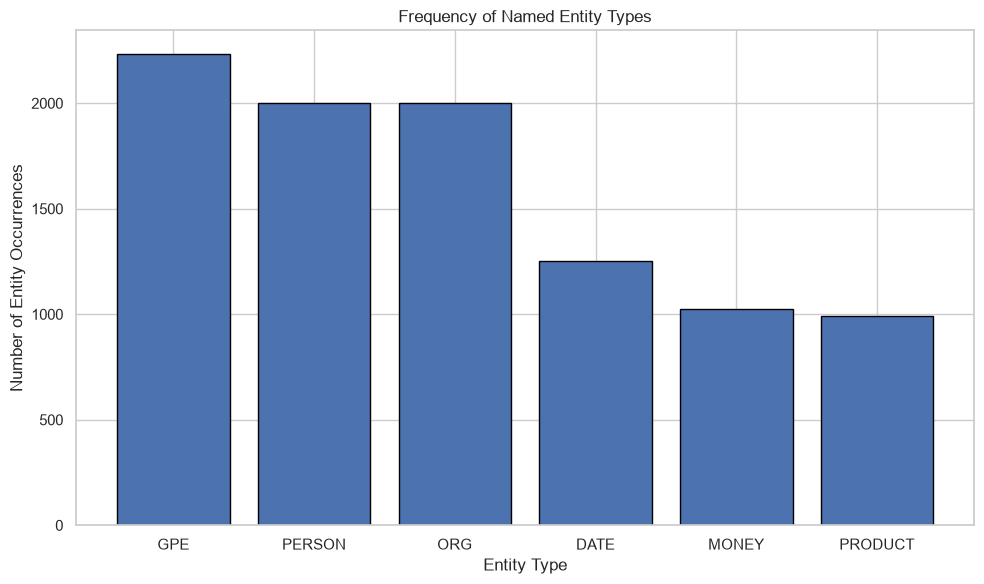

In [134]:
plt.figure(figsize=(10, 6))

plt.bar(
    entity_frequency_df.index,
    entity_frequency_df["count"],
    edgecolor="black"
)

plt.title("Frequency of Named Entity Types")
plt.xlabel("Entity Type")
plt.ylabel("Number of Entity Occurrences")

plt.tight_layout()
plt.show()

In [135]:
most_common_entity = entity_frequency_df.index[0]
most_common_count = entity_frequency_df.iloc[0]["count"]

print(
    f"Most common entity type: {most_common_entity}"
)

print(
    f"Number of occurrences: {most_common_count}"
)

Most common entity type: GPE
Number of occurrences: 2233


### Q6.3 Interpretation

The bar chart shows the frequency of each named entity type across the complete dataset. The most common entity type is identified directly from the calculated frequencies. Because the dataset was synthetically generated using structured templates, some entity types may occur more frequently because they are included in more sentence patterns or because particular sentence templates consistently contain those types.

In [136]:
money_pattern = re.compile(
    r"""
    (?:
        [$€£]\s?\d+(?:,\d{3})*(?:\.\d{2})?
        |
        \d+(?:,\d{3})*(?:\.\d{2})?\s?(?:USD|EUR|GBP)
    )
    """,
    re.VERBOSE | re.IGNORECASE
)

In [137]:
money_test_text = """
The product costs $199.99 and the shipping fee is $25.00.
Another version costs €500.
"""

print("Text:")
print(money_test_text)

print("\nDetected MONEY entities:")

matches = money_pattern.findall(money_test_text)

for match in matches:
    print(match)

Text:

The product costs $199.99 and the shipping fee is $25.00.
Another version costs €500.


Detected MONEY entities:
$199.99
$25.00
€500


In [139]:
def normalize_money(value):
    if pd.isna(value):
        return set()
    
    value = str(value).strip()
    
    if not value or value.lower() == "nan":
        return set()
    
    parts = value.split("|")
    
    return {
        part.strip().lower()
        for part in parts
        if part.strip()
    }

In [140]:
true_positive = 0
false_positive = 0
false_negative = 0

money_evaluation = []

for _, row in ner_df.iterrows():
    
    text = str(row["text"])
    
    predicted_money = {
        match.strip().lower()
        for match in money_pattern.findall(text)
    }
    
    actual_money = normalize_money(
        row["money"]
    )
    
    tp = len(
        predicted_money & actual_money
    )
    
    fp = len(
        predicted_money - actual_money
    )
    
    fn = len(
        actual_money - predicted_money
    )
    
    true_positive += tp
    false_positive += fp
    false_negative += fn
    
    money_evaluation.append({
        "text": text,
        "actual": actual_money,
        "predicted": predicted_money,
        "TP": tp,
        "FP": fp,
        "FN": fn
    })

In [141]:
money_precision = (
    true_positive /
    (true_positive + false_positive)
    if (true_positive + false_positive) > 0
    else 0
)

money_recall = (
    true_positive /
    (true_positive + false_negative)
    if (true_positive + false_negative) > 0
    else 0
)

print("MONEY Entity Extractor")
print("=" * 50)

print(f"True Positives:  {true_positive}")
print(f"False Positives: {false_positive}")
print(f"False Negatives: {false_negative}")

print(f"\nPrecision: {money_precision:.4f}")
print(f"Recall:    {money_recall:.4f}")

MONEY Entity Extractor
True Positives:  1027
False Positives: 0
False Negatives: 0

Precision: 1.0000
Recall:    1.0000


In [142]:
for result in money_evaluation[:10]:
    print("=" * 100)
    print("Text:", result["text"])
    print("Actual:", result["actual"])
    print("Predicted:", result["predicted"])
    print(
        f"TP={result['TP']}, "
        f"FP={result['FP']}, "
        f"FN={result['FN']}"
    )

Text: Isabella Brown joined Maple Street School District in Warsaw on March 22, 2022 to launch a PureGlow skincare set.
Actual: set()
Predicted: set()
TP=0, FP=0, FN=0
Text: On July 18, 2016, Oakwood Publishing House opened a new branch in Seoul, Malaysia, appointing Maria Larsen as director.
Actual: set()
Predicted: set()
TP=0, FP=0, FN=0
Text: The board at Skyline Real Estate approved a $75 investment in Berlin after Yuki Lewis's presentation on July 14, 2025.
Actual: {'$75'}
Predicted: {'$75'}
TP=1, FP=0, FN=0
Text: During the conference in Toronto, Hana Brown from Union Manufacturing Corp. unveiled a SoundWave headset priced at $199.
Actual: {'$199'}
Predicted: {'$199'}
TP=1, FP=0, FN=0
Text: Zenith Pharmaceuticals announced that Ravi Silva will lead the new office in Berlin starting June 11, 2018.
Actual: set()
Predicted: set()
TP=0, FP=0, FN=0
Text: The board at Aurora Data Systems approved a $9.99 investment in Copenhagen after Noah Haddad's presentation on September 1, 2022.
Ac

### Q6.4 Interpretation

A regular-expression-based rule was used to identify monetary expressions in the text. The extractor was evaluated against the dataset's ground-truth money column using precision and recall. Because the dataset uses relatively clean and structured synthetic sentences, a simple regular expression can perform well when monetary expressions follow predictable formats; however, such rules can be less reliable when money is expressed in unexpected ways.

### Q6.5 Discussion

Rule-based NER systems depend on manually designed patterns, so they work well only when entities follow predictable formats. A purely statistical NER system can learn useful patterns from training data, but its performance can decrease when the text differs significantly from the training examples. Neural and Transformer-based NER systems can capture richer contextual relationships between words and are generally more flexible when dealing with varied language. This becomes especially important in real-world text such as social media, where spelling mistakes, abbreviations, emojis, slang, hashtags, and incomplete sentences are common. Rule-based systems may miss entities when their wording does not match the predefined patterns, while statistical systems may struggle with unfamiliar entities or contexts. Transformer-based models usually require more computational resources and suitable training or fine-tuning data, but they can provide stronger contextual understanding than simple rules.